## Human Activity Recognition for Healthy Lifestyle Monitoring

This project focuses on building a machine learning pipeline to classify five basic human activities: sitting down, standing up, walking, running, and climbing stairs—using smartphone sensor data (accelerometer, gyroscope, gravity).  

**Background and Relevance :**
Human Activity Recognition (HAR) using wearable sensors plays a key role in modern health monitoring, as seen in fitness trackers and smartwatches. Reliable detection of daily activities can support healthy lifestyle interventions, especially for elderly populations. This assignment focuses on five core activities, sitting down, standing up, walking, running, and climbing stairs, to explore how sensor-based data can be transformed into actionable insights for wellness and digital health applications.

**Aim and Research Questions :**
The goal is to develop and evaluate machine learning models that classify these activities using smartphone sensor data to support healthy lifestyle monitoring.

Key questions to address:
1. Which sensor-derived features best distinguish the five target activities?
2. How do supervised vs. unsupervised learning approaches compare for this classification task?
3. Which model achieves the highest accuracy and reliability when combined with appropriate feature extraction and selection?
4. What are the practical considerations and limitations for deploying such systems in real-world health monitoring contexts?


Import Libraries:

In [99]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [100]:
import sys
import os
from pathlib import Path
import pandas as pd
import importlib
import  shutil
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Add the src folder to the Python module search path
sys.path.append(os.path.abspath("src"))
PROJECT_ROOT = Path.cwd().resolve()
RAW_BASE   = PROJECT_ROOT / "data" / "raw"
TRIMMED_BASE = PROJECT_ROOT / "data" / "trimmed_data"

from data_loader import *
from visualization import *
from preprocessing import *

# Load all data into memory
all_data = load_all_data(RAW_BASE, print_option=False)

Data Loaded
Raw Data Classes: ['running', 'sit_down', 'stairs', 'stand_up', 'walking']


### Data Collection Procedure

We used two different methods for collecting activity data:

1. **Continuous recordings**  
   - Applied to activities such as **running, walking, and climbing stairs**.  
   - These activities can be performed continuously without interruption.  
   - As a result, the recordings are relatively long.

     **Recording Procedure:** The smartphone was secured on the subject’s left arm while standing still. The recording began in this position, after which the subject performed the activity, running, walking, or climbing stairs, in a straight line. Once the activity was completed, the subject remained still until the recording was stopped.
     
2. **Single-instance recordings**  
   - Applied to **sitting down** and **standing up** activities.  
   - Each recording contains **only one instance** of the activity.  
   - These recordings are therefore relatively short.

     **Recording Procedure:** For the sitting-down activity, the smartphone was secured on the subject’s left arm while they stood still in front of a chair. Recording began, and after 1–2 seconds the subject performed the sitting-down action. The recording continued for another 1–2 seconds while the subject remained seated, then was stopped. The same procedure was followed for the standing-up activity.

Below are the visualized plots of **raw** accelerometer, gyroscope, and gravity sensor recordings from randomly selected samples of each activity group.

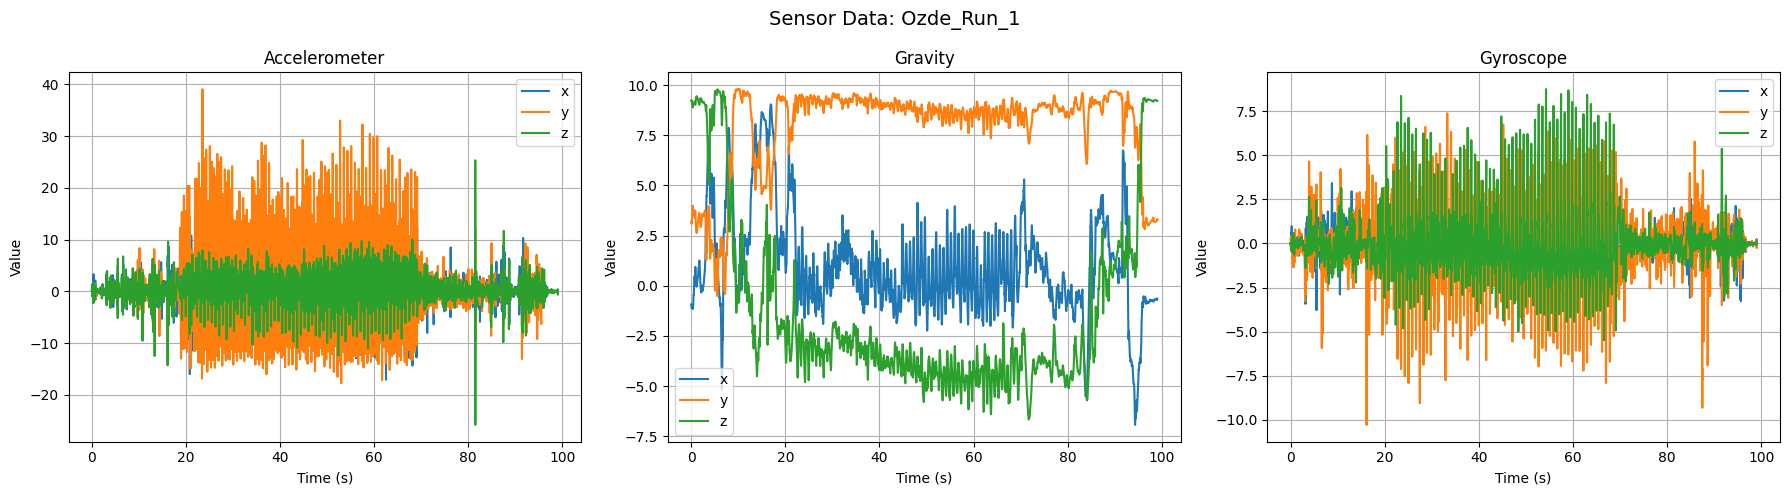

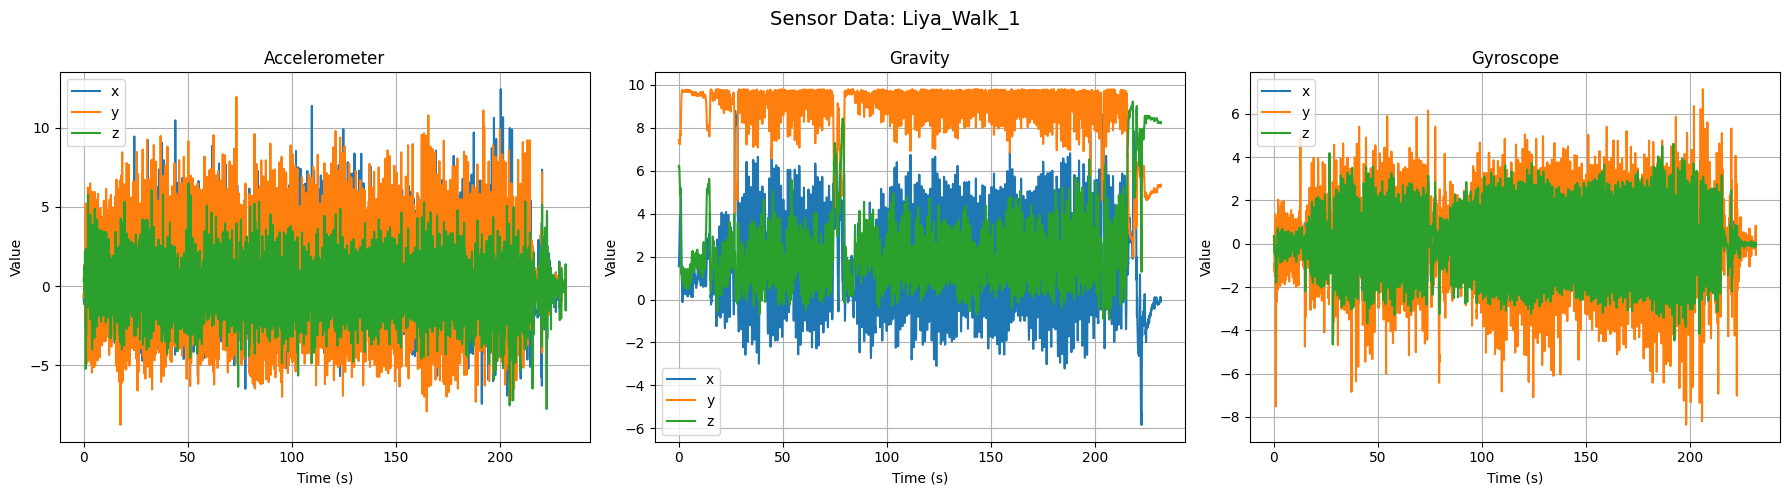

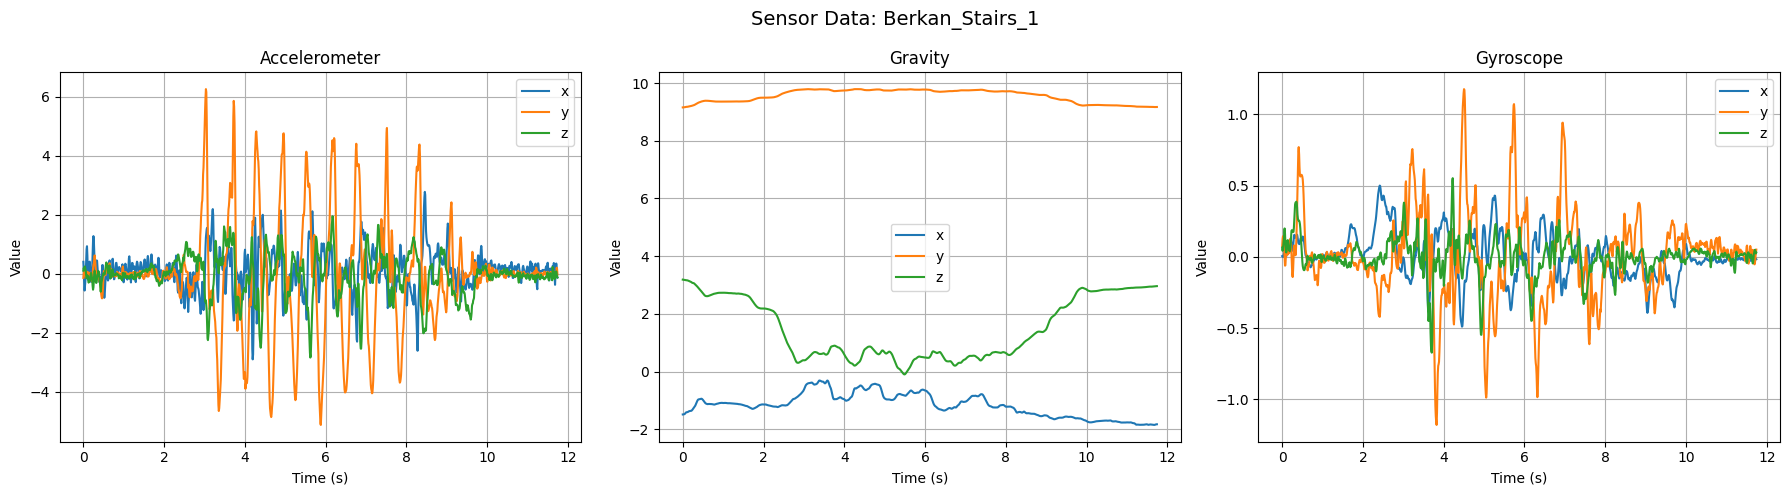

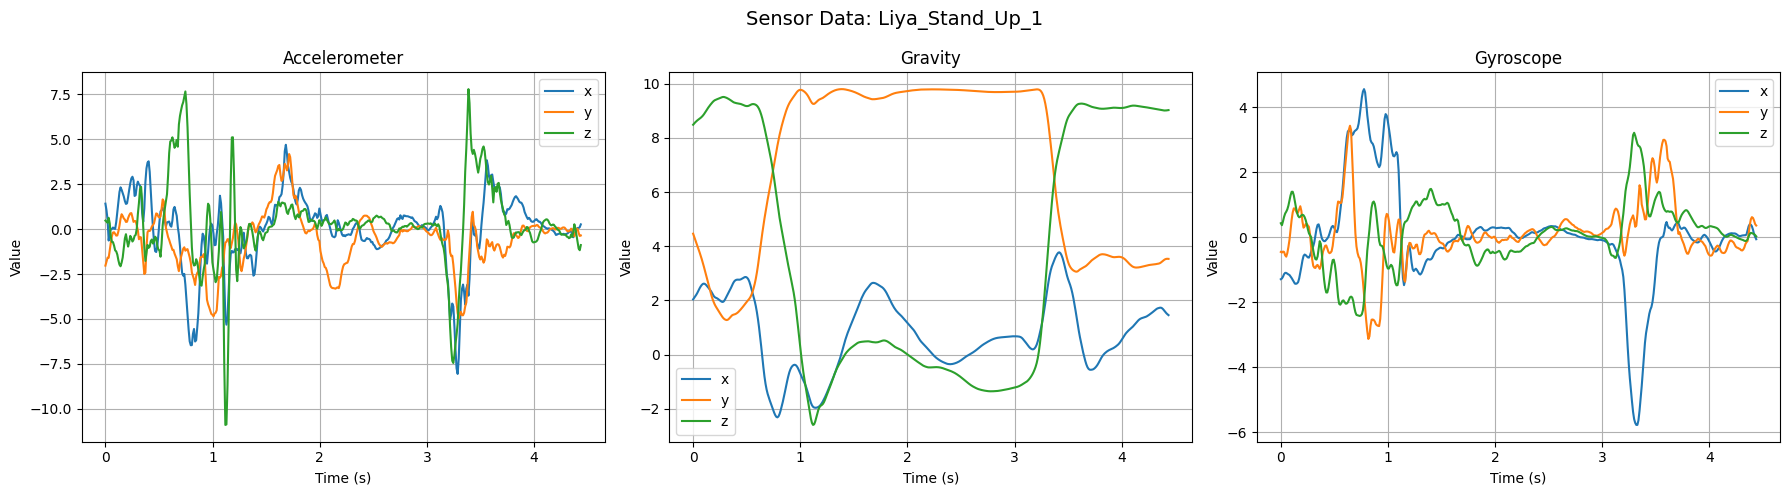

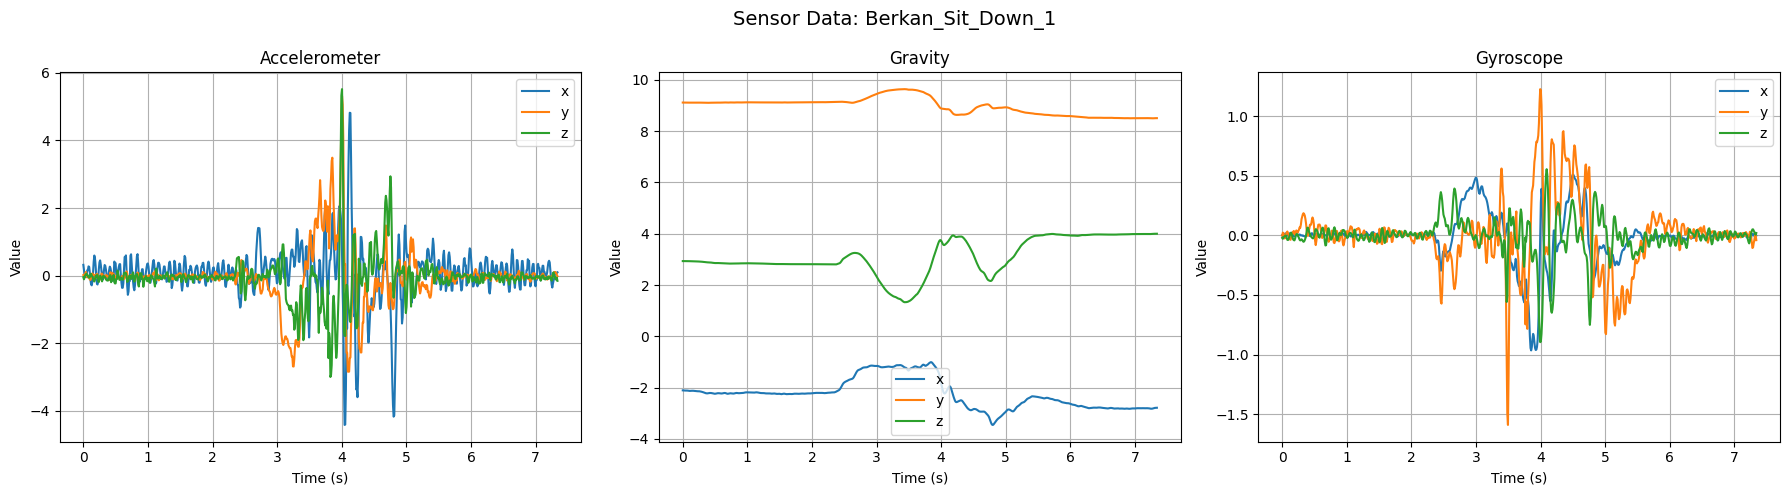

In [101]:
plot_activity(RAW_BASE / "running" / "Ozde_Run_1")
plot_activity(RAW_BASE / "walking" / "Liya_Walk_1")
plot_activity(RAW_BASE / "stairs" / "Berkan_Stairs_1")
plot_activity(RAW_BASE / "stand_up" / "Liya_Stand_Up_1")
plot_activity(RAW_BASE / "sit_down" / "Berkan_Sit_Down_1")

We start processing the raw data by first removing the inactive segments at the beginning and end of each recording, retaining only the portion where the activity is actually performed.
Additionally, we discard any segments recorded while placing the phone into the armband, as these movements do not represent the target activity.

- **For Continuous activities (running / walking / climbing stairs):** Each recording was trimmed to remove non-activity segments and then divided into multiple data samples using 3-second windows with 50% overlap.

In [102]:
WINDOW_SIZE = 3.0 #Seconds

preprocess_running(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False) # show_plots=False to disable plots
preprocess_walking(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False) # show_plots=False to disable plots
preprocess_stairs(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False)  # show_plots=False to disable plots


 Processing running | Folder: Ozde_Run_1
  Trim 20.96 → 67.26, 29 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_data/running

 Processing running | Folder: Berkan_Run_2
  Trim 7.51 → 67.41, 39 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_data/running

 Processing running | Folder: Ozde_Run_3
  Trim 19.47 → 80.70, 39 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_data/running

 Processing running | Folder: Ozde_Run_4
  Trim 17.98 → 79.21, 39 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_data/running

 Processing running | Folder: Ozde_Run_5
  Trim 17.97 → 91.14, 47 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_da

Example plot of the RMS Intersection Based Trim Detection Procedure for Raw Running Recordings:

![](figures\running_rms_intersection_based_trim_detection.png)

[Explanation of this plot goes here: How the RMS energy used to find the trimming points etc.]

Example plot of the RMS Intersection Based Trim Detection Procedure for Raw Walking Recordings:

![](figures\walking_rms_intersection_based_trim_detection.png)

[Explanation of this plot goes here: How the RMS energy used to find the trimming points etc.]

- **For single-instance activities (sit-down / stand-up):**
Each single-instance activity (sit-down / stand-up) was trimmed to a 3-second window, centered on the activity itself, to remove non-activity segments.

In [103]:
WINDOW_SIZE = 3.0 #Seconds

results = trim_sitdown_standup(RAW_BASE, TRIMMED_BASE, window_size=WINDOW_SIZE)

Done. Processed: 90 | Skipped: 0


[An explanation of the trimming procedure of sitdown and standup activities will added here with a plot]

Now we can collect all windowed activity data into a single CSV file.

[Also Explain which/why features are extracted from x, y and z sensor recordings]

In [104]:
from create_csv import *

DATASET_PATH = PROJECT_ROOT / "dataset.csv"

audit_windows(TRIMMED_BASE)
df = build_dataset_from_windowed_data(TRIMMED_BASE, DATASET_PATH, keep_ids=True)

[Audit]
  - running: expected=276, usable=276, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - sit_down: expected=45, usable=45, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - stairs: expected=60, usable=60, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - stand_up: expected=45, usable=45, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - walking: expected=481, usable=481, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}

Total window folders: 907 | Usable (all three files OK): 907

[Activity] running
  Processed 250 windows...

[Activity] sit_down

[Activity] stairs

[Activity] stand_up

[Activity] walking
  Processed 500 windows...
  Processed 750 windows...

[Done] Wrote 907 rows × 167 columns to: /U

## Load the dataset
- First column is label (y)
- Remaining are features (X)

In [105]:
DATASET_PATH = PROJECT_ROOT / "dataset.csv"

df = pd.read_csv(DATASET_PATH)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print("Loaded dataset.csv with shape:", df.shape)
print("Target name:", df.columns[0])
print("Num features:", X.shape[1])

df.head(3)# 12345

Loaded dataset.csv with shape: (907, 167)
Target name: activity
Num features: 166


,activity,acc_corr_x_y,acc_corr_x_z,acc_corr_y_z,acc_mag_dom_freq,acc_mag_iqr,acc_mag_kurtosis,acc_mag_max,acc_mag_mean,acc_mag_median,...,gyro_z_mean,gyro_z_median,gyro_z_min,gyro_z_rms,gyro_z_skew,gyro_z_spec_centroid,gyro_z_spec_energy,gyro_z_spec_entropy,gyro_z_std,person
0,running,-0.422285,-0.255755,-0.025324,5.0,6.662222,-0.093018,23.414247,9.195592,9.040583,...,-0.017501,-0.035374,-1.221355,0.420798,0.278885,4.202507,11.759396,3.036354,0.421137,Berkan
1,running,-0.068380,-0.043782,-0.262769,5.0,5.756685,-0.737154,18.871659,9.020759,9.577971,...,0.038710,0.124412,-1.495412,0.619739,-0.194350,2.548933,19.232855,2.127987,0.619562,Berkan
2,running,-0.110942,0.009237,-0.290851,5.0,5.511045,-0.709310,17.660803,8.971730,9.589745,...,0.085773,0.187724,-1.495412,0.598747,-0.249874,2.659217,22.169449,2.251347,0.593562,Berkan


## Split data into Train and Test set
We split the data into training and test datsets with a 80/20 train/test ratio. This is done in a stratified manner. Afterwards we scale the data for effective training.


In [106]:
# imports
from sklearn.preprocessing import StandardScaler
from preprocessing import stratified_person_label_split

X_train, y_train, X_test, y_test, info = stratified_person_label_split(X,y,test_ratio=0.20,random_state=42)

print(info["sizes"])
print(info["ratios"])
print("Classes:", info["class_dist"])
print("People:", info["person_dist"])

# --- StandardScaler setup ---
scaler = StandardScaler()

print(X_train.dtypes)
print(X_train.head())

# Keep only numeric columns
X_train_num = X_train.select_dtypes(include=["number"])
X_test_num  = X_test.select_dtypes(include=["number"])

# Scale numeric features only
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num),
    columns=X_train_num.columns,
    index=X_train.index)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_num),
    columns=X_test_num.columns,
    index=X_test.index)


{'train': 726, 'test': 181, 'total': 907}
{'train': 0.8004410143329658, 'test': 0.19955898566703417}
Classes: {'train': {'running': 221, 'sit_down': 36, 'stairs': 48, 'stand_up': 36, 'walking': 385}, 'test': {'running': 55, 'sit_down': 9, 'stairs': 12, 'stand_up': 9, 'walking': 96}}
People: {'train': {'Berkan': 172, 'Liya': 329, 'Ozde': 225}, 'test': {'Berkan': 43, 'Liya': 82, 'Ozde': 56}}
acc_corr_x_y            float64
acc_corr_x_z            float64
acc_corr_y_z            float64
acc_mag_dom_freq        float64
acc_mag_iqr             float64
                         ...   
gyro_z_spec_centroid    float64
gyro_z_spec_energy      float64
gyro_z_spec_entropy     float64
gyro_z_std              float64
person                   object
Length: 166, dtype: object
     acc_corr_x_y  acc_corr_x_z  acc_corr_y_z  acc_mag_dom_freq  acc_mag_iqr  \
805      0.035475      0.076941      0.417621          1.683502     1.833870   
584     -0.001753      0.131022      0.187155          2.020202     

# Feature Selection
- **Filter Methods:** Variance -> Correlation -> Mutual Information
- **Wrapper Methods:** Recursive Feature Elimination (RFE) + Sequential Feature Selection (SFS) forward/backward

All performed on `dataset.csv` (explained above how this dataset is obtained).


In [107]:
## Imports & Code Paths 

import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate, GridSearchCV, learning_curve
from sklearn.metrics import make_scorer, accuracy_score, cohen_kappa_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.decomposition import PCA
from functools import partial
from sklearn.metrics import accuracy_score, silhouette_score 
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


# Our feature selection toolkit (from feature_selection.py)
from feature_selection import (
    filter_select,
    wrapper_select,
    plot_correlation_heatmap,
    accuracy_vs_k_MI
)

import os
# Paths & directories (safe to run multiple times)
# (Creates ./figures if it doesn't exist for saved plots)
os.makedirs("figures", exist_ok=True)


## Filter Methods
We use 3 filters succesively:
- **Variance:** Removes exactly-constant (dead) features
- **Correlation:** Drop one of each highly correlated pair of features
- **Mutual Information (MI):** Keep top-K features by MI with class labels 

In [108]:
# FILTERS: variance -> correlation -> MI-KBest
Xf_train, names_f, report = filter_select(
    X_train_scaled, y_train,
    variance_thresh=0.0,       #threshold for removing ONLY exactly-constant features
    corr_thresh=0.90,          #feature-feature absolute correlation threshold
    k_best=40,                 #integer: keep top-k by mutual information; None to skip
    scale_for_mi=True,         
    mi_n_neighbors=5,          #how many neighbors to use for MI selection
    mi_random_state=42         #fixed random_state for reproducibility
)
print("Filter report:", report)

# Apply same feature subset to both train and test
X_train_fs = X_train_scaled[names_f]
X_test_fs  = X_test_scaled[names_f]

[VarianceThreshold] Kept: 165, Removed: 0
[CorrelationFilter] Kept: 107, Removed: 58 (|r| > 0.9)
Removed highly correlated features: ['acc_mag_max', 'acc_mag_mean', 'acc_mag_median', 'acc_mag_rms', 'acc_mag_spec_energy', 'acc_mag_std', 'acc_x_min', 'acc_x_rms', 'acc_x_spec_energy', 'acc_x_std', 'acc_y_iqr', 'acc_y_max', 'acc_y_min', 'acc_y_rms', 'acc_y_spec_energy', 'acc_y_std', 'acc_z_iqr', 'acc_z_mean', 'acc_z_median', 'acc_z_rms', 'acc_z_spec_energy', 'acc_z_std', 'grav_mag_iqr', 'grav_mag_median', 'grav_mag_rms', 'grav_mag_spec_energy', 'grav_mag_std', 'grav_x_median', 'grav_x_spec_energy', 'grav_x_std', 'grav_y_median', 'grav_y_rms', 'grav_y_spec_energy', 'grav_y_std', 'grav_z_max', 'grav_z_mean', 'grav_z_median', 'grav_z_min', 'grav_z_std', 'gyro_mag_max', 'gyro_mag_mean', 'gyro_mag_median', 'gyro_mag_rms', 'gyro_mag_spec_energy', 'gyro_mag_std', 'gyro_x_std', 'gyro_y_max', 'gyro_y_min', 'gyro_y_rms', 'gyro_y_spec_energy', 'gyro_y_std', 'gyro_z_iqr', 'gyro_z_max', 'gyro_z_min', '

Baseline CV performance (5-fold, training set only):

LogisticRegression:
  Accuracy : 0.9821 ± 0.0127
  Kappa    : 0.9710 ± 0.0206
  F1-macro : 0.9603 ± 0.0239

KNN:
  Accuracy : 0.9697 ± 0.0119
  Kappa    : 0.9511 ± 0.0191
  F1-macro : 0.9184 ± 0.0222

NaiveBayes:
  Accuracy : 0.9435 ± 0.0147
  Kappa    : 0.9104 ± 0.0230
  F1-macro : 0.8848 ± 0.0406

DecisionTree:
  Accuracy : 0.9752 ± 0.0112
  Kappa    : 0.9601 ± 0.0178
  F1-macro : 0.9356 ± 0.0362


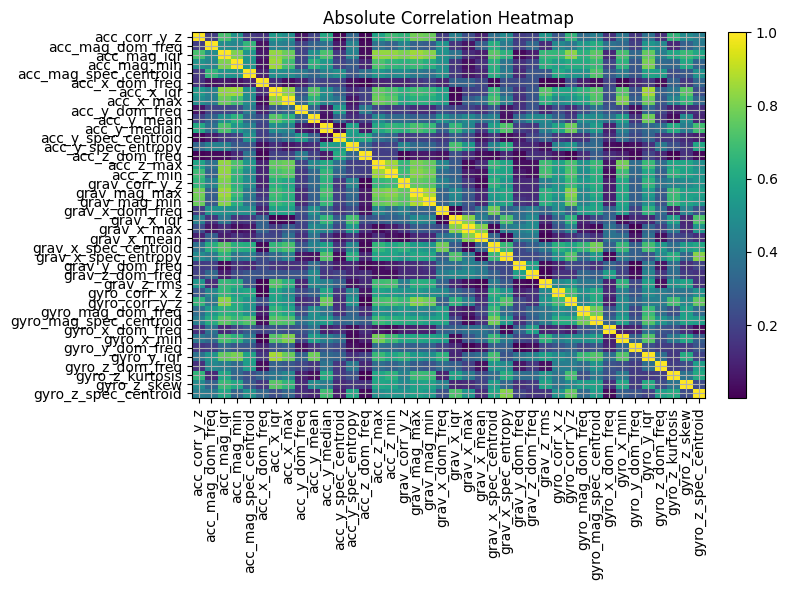

Saved correlation heatmap to corr_heatmap.png


In [109]:
#Intermediate Results
#Baseline models on filtered features (accuracy on held-out test set )
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

# Define custom scorers
scorers = {
    "accuracy": make_scorer(accuracy_score),
    "kappa": make_scorer(cohen_kappa_score),
    "f1_macro": make_scorer(f1_score, average="macro")  # macro for multiclass
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Baseline CV performance (5-fold, training set only):")
for name, clf in models.items():
    cv_results = cross_validate(clf, X_train_fs.values, y_train, cv=cv, scoring=scorers)
    acc_mean, acc_std = cv_results["test_accuracy"].mean(), cv_results["test_accuracy"].std()
    kappa_mean, kappa_std = cv_results["test_kappa"].mean(), cv_results["test_kappa"].std()
    f1_mean, f1_std = cv_results["test_f1_macro"].mean(), cv_results["test_f1_macro"].std()

    print(f"\n{name}:")
    print(f"  Accuracy : {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"  Kappa    : {kappa_mean:.4f} ± {kappa_std:.4f}")
    print(f"  F1-macro : {f1_mean:.4f} ± {f1_std:.4f}")

# Optional: visualize correlation after variance filtering
# Correlation heatmap (saved to figures/, non-blocking)
plot_correlation_heatmap(pd.DataFrame(Xf_train, columns=names_f), show=True, block=False, save_path="figures/corr_heatmap.png")
print("Saved correlation heatmap to corr_heatmap.png")

[VarianceThreshold] Kept: 165, Removed: 0
[CorrelationFilter] Kept: 128, Removed: 37 (|r| > 0.95)
Removed highly correlated features: ['acc_mag_mean', 'acc_mag_median', 'acc_mag_rms', 'acc_mag_spec_energy', 'acc_mag_std', 'acc_x_rms', 'acc_x_spec_energy', 'acc_x_std', 'acc_y_iqr', 'acc_y_max', 'acc_y_min', 'acc_y_rms', 'acc_y_spec_energy', 'acc_y_std', 'acc_z_iqr', 'acc_z_median', 'acc_z_rms', 'acc_z_spec_energy', 'acc_z_std', 'grav_mag_rms', 'grav_mag_spec_energy', 'grav_mag_std', 'grav_x_median', 'grav_x_spec_energy', 'grav_x_std', 'grav_y_rms', 'grav_z_mean', 'grav_z_median', 'grav_z_std', 'gyro_mag_median', 'gyro_mag_rms', 'gyro_mag_std', 'gyro_x_std', 'gyro_y_rms', 'gyro_y_std', 'gyro_z_spec_energy', 'gyro_z_std']
Correlated pairs (kept -> removed, r):
  acc_mag_iqr -> acc_mag_mean (r=0.967)
  acc_mag_max -> acc_mag_mean (r=0.951)
  acc_mag_mean -> acc_mag_median (r=0.992)
  acc_mag_iqr -> acc_mag_rms (r=0.975)
  acc_mag_max -> acc_mag_rms (r=0.964)
  acc_mag_mean -> acc_mag_rms (

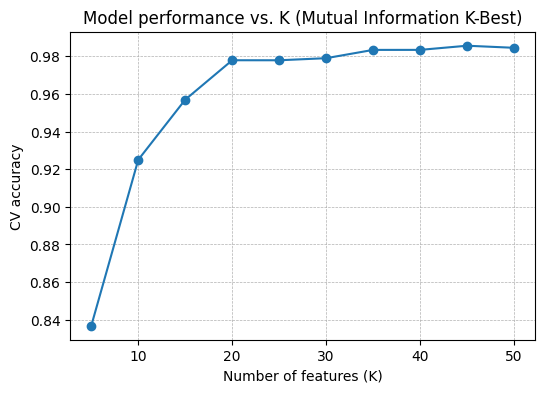

Saved MI K-curve to figures/mi_k_curve.png


In [110]:
# Keep only numeric features
X_num = X.select_dtypes(include=["number"])

# MI curve
ks, accs = accuracy_vs_k_MI(
    X_num, y,
    estimator=LogisticRegression(max_iter=2000, solver="lbfgs"),
    show=True, block=False, save_path="figures/mi_k_curve.png"
)
print("Saved MI K-curve to figures/mi_k_curve.png")

## Wrapper Methods
XXXXX

In [111]:
# Wrapper: RFE + Logistic Regression (CV summary on train only)
Xw_lr_train, features_lr, info_lr = wrapper_select(
    X_train_fs, y_train,
    method="rfe",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    cv_splits=5,
    scale_inputs=True
)

[Wrapper-RFE] Kept: 15 features
  Accuracy : 0.9876 ± 0.0119
  Kappa    : 0.9799 ± 0.0191
  F1-macro : 0.9629 ± 0.0403
  Selected features: ['acc_corr_y_z', 'acc_mag_dom_freq', 'acc_mag_iqr', 'acc_mag_spec_centroid', 'acc_y_mean', 'acc_y_median', 'acc_y_spec_centroid', 'acc_y_spec_entropy', 'acc_z_min', 'grav_z_rms', 'gyro_mag_dom_freq', 'gyro_mag_spec_centroid', 'gyro_x_min', 'gyro_y_iqr', 'gyro_z_spec_centroid']


In [112]:
# Wrapper: SFS (forward) + KNN (works well for distance-based models)
Xw_knn_train, features_knn, info_knn = wrapper_select(
    X_train_fs, y_train,
    method="sfs_forward",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=KNeighborsClassifier(n_neighbors=5),
    cv_splits=5,
    scale_inputs=True
)

[Wrapper-SFS:forward] Kept: 15 features
  Accuracy : 0.9959 ± 0.0034
  F1-macro : 0.9893 ± 0.0097
  Kappa    : 0.9933 ± 0.0055
  Selected features: ['acc_corr_y_z', 'acc_mag_dom_freq', 'acc_mag_iqr', 'acc_mag_min', 'acc_x_iqr', 'acc_x_max', 'acc_y_mean', 'acc_y_median', 'acc_y_spec_centroid', 'acc_y_spec_entropy', 'grav_mag_max', 'grav_x_dom_freq', 'grav_x_iqr', 'grav_x_mean', 'gyro_corr_x_z']


In [113]:
# Wrapper: SFS (forward) + Naive Bayes
Xw_nb_train, features_nb, info_nb = wrapper_select(
    X_train_fs, y_train,
    method="sfs_forward",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=GaussianNB(),
    cv_splits=5,
    scale_inputs=True
)

[Wrapper-SFS:forward] Kept: 15 features
  Accuracy : 0.9862 ± 0.0000
  F1-macro : 0.9640 ± 0.0121
  Kappa    : 0.9776 ± 0.0001
  Selected features: ['acc_corr_y_z', 'acc_mag_iqr', 'acc_mag_spec_centroid', 'acc_x_dom_freq', 'acc_y_median', 'acc_y_spec_centroid', 'acc_z_dom_freq', 'acc_z_min', 'grav_corr_y_z', 'grav_x_mean', 'gyro_corr_x_z', 'gyro_corr_y_z', 'gyro_mag_dom_freq', 'gyro_x_min', 'gyro_y_iqr']


In [114]:
# Wrapper: RFE + Decision Tree (trees don't need scaling)
Xw_dt_train, features_dt, info_dt = wrapper_select(
    X_train_fs, y_train,
    method="rfe",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=DecisionTreeClassifier(random_state=42),
    cv_splits=5,
    scale_inputs=False
)

[Wrapper-RFE] Kept: 15 features
  Accuracy : 0.9780 ± 0.0110
  Kappa    : 0.9644 ± 0.0178
  F1-macro : 0.9375 ± 0.0334
  Selected features: ['acc_mag_iqr', 'acc_y_dom_freq', 'acc_y_mean', 'acc_y_median', 'acc_y_spec_centroid', 'acc_y_spec_entropy', 'grav_x_spec_centroid', 'grav_x_spec_entropy', 'grav_y_dom_freq', 'grav_z_dom_freq', 'grav_z_rms', 'gyro_x_dom_freq', 'gyro_x_min', 'gyro_y_dom_freq', 'gyro_y_iqr']


### Creating subsets with the selected features per model

In [115]:
# 1) Collect the per-model selected feature names
feature_sets = {
    "lr":  features_lr,   # from wrapper RFE + Logistic Regression
    "knn": features_knn,  # from wrapper SFS + KNN
    "nb":  features_nb,   # from wrapper SFS + Naive Bayes
    "dt":  features_dt,   # from wrapper RFE + Decision Tree
}

# 2) Create subsets directly (train/test; add val block if you have it)
X_train_lr = X_train_scaled[feature_sets["lr"]]
X_test_lr  = X_test_scaled[feature_sets["lr"]]

X_train_knn = X_train_scaled[feature_sets["knn"]]
X_test_knn  = X_test_scaled[feature_sets["knn"]]

X_train_nb = X_train_scaled[feature_sets["nb"]]
X_test_nb  = X_test_scaled[feature_sets["nb"]]

X_train_dt = X_train_scaled[feature_sets["dt"]]
X_test_dt  = X_test_scaled[feature_sets["dt"]]

print("Subset sizes (rows = samples, cols = features):")
print(f"  LR  → train: {X_train_lr.shape}, test: {X_test_lr.shape}")
print(f"  KNN → train: {X_train_knn.shape}, test: {X_test_knn.shape}")
print(f"  NB  → train: {X_train_nb.shape}, test: {X_test_nb.shape}")
print(f"  DT  → train: {X_train_dt.shape}, test: {X_test_dt.shape}")

Subset sizes (rows = samples, cols = features):
  LR  → train: (726, 15), test: (181, 15)
  KNN → train: (726, 15), test: (181, 15)
  NB  → train: (726, 15), test: (181, 15)
  DT  → train: (726, 15), test: (181, 15)


# Supervised Learning Methods

Different supervised learning methods are trained:
- A Logistic Regression model (LR)
- A Decision Tree (DT)
- A Naive Bayes classifier (NB)
- K-Nearest Neighbor algorithm (kNN)

Each of these is trained using their own subset of features which were selected during the feature selection phase.

Every model is trained using cross-validation adn is evaluated using the three scorers: Accuracy, Cohen's Kappa, and F1-score, as been done earlier in the notebook too.

For every model, their respective hyperparameters are tuned using gridsearch.

In [116]:
# CELL 1 — shared setup (run once)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd

# Scorers: accuracy, Cohen's kappa, and macro-F1 for 5-class setup
scorers = {
    "accuracy": "accuracy",
    "kappa": make_scorer(cohen_kappa_score),
    "f1_macro": "f1_macro",
}

# pick one of these
refit_metric = "kappa"      
# refit_metric = "f1_macro"  
# refit_metric = "accuracy"  

# 5-fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def summarize_grid_search(gs):
    print("Best params:", gs.best_params_)
    print("Refit scorer:", gs.refit)
    print("Best CV score (refit metric):", gs.best_score_)

    # Show mean CV scores for all scorers at the best params
    means = gs.cv_results_["mean_test_accuracy"][gs.best_index_], \
            gs.cv_results_["mean_test_kappa"][gs.best_index_], \
            gs.cv_results_["mean_test_f1_macro"][gs.best_index_]
    print({"mean_accuracy": means[0], "mean_kappa": means[1], "mean_f1_macro": means[2]})


In [117]:
# CELL 2 — Logistic Regression
# Use your model-specific training frame with 15 selected features
# X_logreg_train: pandas DataFrame of shape (n_samples, 15)
# y_train: 1D array-like of class labels (5 classes)

from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="lbfgs",
        #class_weight="balanced",
        random_state=42 ))
])

param_grid_lr = {
    "clf__C": np.logspace(-3, 2, 10),          # 0.001 ... 100
    "clf__max_iter": [500, 1000, 2000, 5000],  # convergence budget
}

gs_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring=scorers,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_lr.fit(X_train_lr, y_train)
summarize_grid_search(gs_lr)

best_logreg = gs_lr.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'clf__C': np.float64(27.825594022071257), 'clf__max_iter': 500}
Refit scorer: kappa
Best CV score (refit metric): 0.979908687328081
{'mean_accuracy': np.float64(0.9876051015588097), 'mean_kappa': np.float64(0.979908687328081), 'mean_f1_macro': np.float64(0.9609124749547201)}


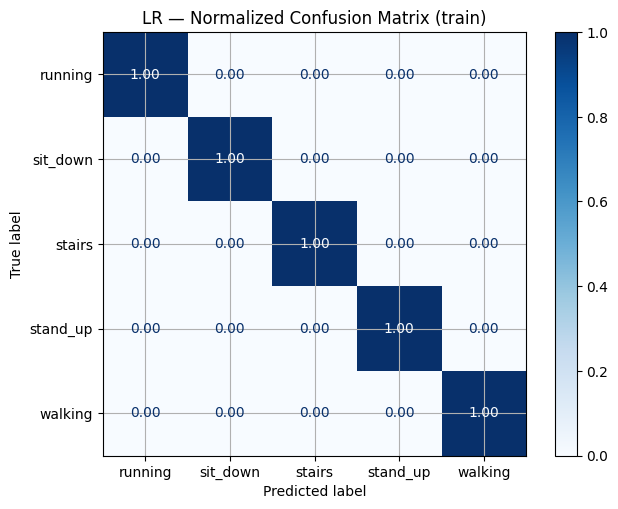

,feature,mean_abs_coef,mean_signed_coef
0,acc_y_median,2.201807,-3.730349e-15
1,acc_y_spec_centroid,1.690165,-7.993606e-16
2,acc_mag_iqr,1.586373,-8.881784e-16
3,gyro_mag_spec_centroid,1.525777,3.552714e-16
4,acc_mag_spec_centroid,1.417086,8.881784e-16
5,gyro_z_spec_centroid,1.287821,2.209344e-15
6,gyro_x_min,1.282867,4.884981e-16
7,acc_y_spec_entropy,1.228770,-3.641532e-15
8,grav_z_rms,1.064619,-1.909584e-15
9,gyro_y_iqr,1.037882,-1.776357e-15


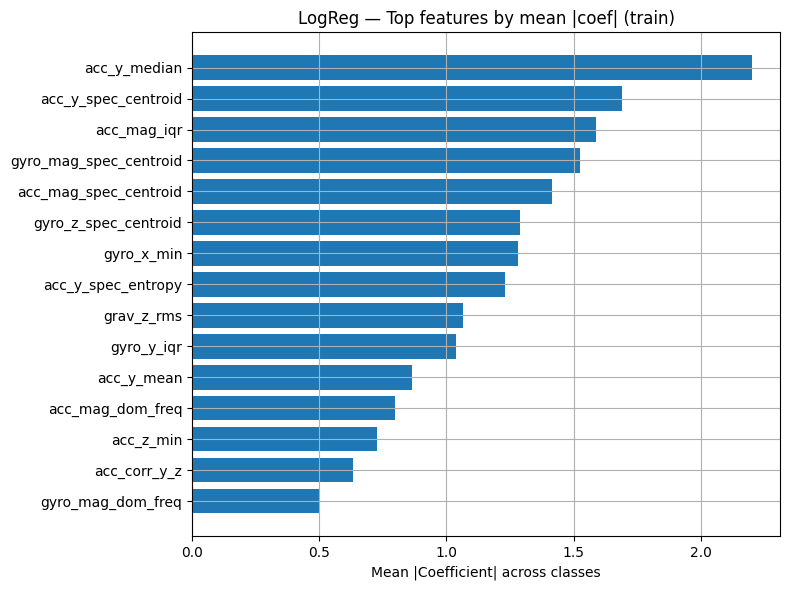

In [118]:
# Logistic Regression — train-set evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 1) Normalized confusion matrix (rows sum to 1)
ConfusionMatrixDisplay.from_estimator(
    best_logreg, X_train_lr, y_train,
    normalize="true", cmap="Blues", values_format=".2f"
)
plt.title("LR — Normalized Confusion Matrix (train)")
plt.show()

# 2) Mean coefficients across classes (top features)
lr = best_logreg.named_steps["clf"] if hasattr(best_logreg, "named_steps") else best_logreg
coefs = lr.coef_  # shape: (n_classes, n_features)

feature_names = list(getattr(X_train_lr, "columns", [f"f{i}" for i in range(coefs.shape[1])]))
mean_abs = np.mean(np.abs(coefs), axis=0)
mean_signed = np.mean(coefs, axis=0)

coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_coef": mean_abs,
        "mean_signed_coef": mean_signed,
    })
    .sort_values("mean_abs_coef", ascending=False)
    .reset_index(drop=True)
)

# Show top 15
display(coef_df.head(15))

# Optional: bar plot for top features by mean |coef|
top = coef_df.head(15).sort_values("mean_abs_coef", ascending=True)
plt.figure(figsize=(8,6))
plt.barh(top["feature"], top["mean_abs_coef"])
plt.xlabel("Mean |Coefficient| across classes")
plt.title("LogReg — Top features by mean |coef| (train)")
plt.tight_layout()
plt.show()


In [119]:
# CELL 3 — Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None] + list(range(2, 31, 2)),
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

gs_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring=scorers,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_dt.fit(X_train_dt, y_train)
summarize_grid_search(gs_dt)

best_dt = gs_dt.best_estimator_

print("Depth:", best_dt.get_depth())
print("Leaves:", best_dt.get_n_leaves())


Fitting 5 folds for each of 512 candidates, totalling 2560 fits
Best params: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Refit scorer: kappa
Best CV score (refit metric): 0.9644826519394016
{'mean_accuracy': np.float64(0.9779499291450164), 'mean_kappa': np.float64(0.9644826519394016), 'mean_f1_macro': np.float64(0.9438664894113135)}
Depth: 4
Leaves: 9


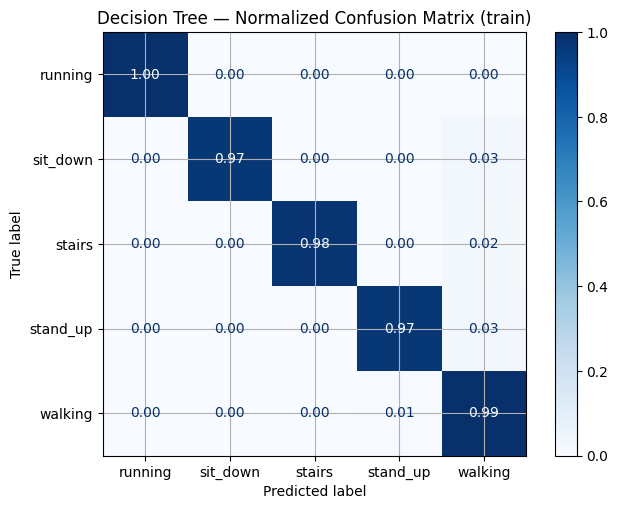

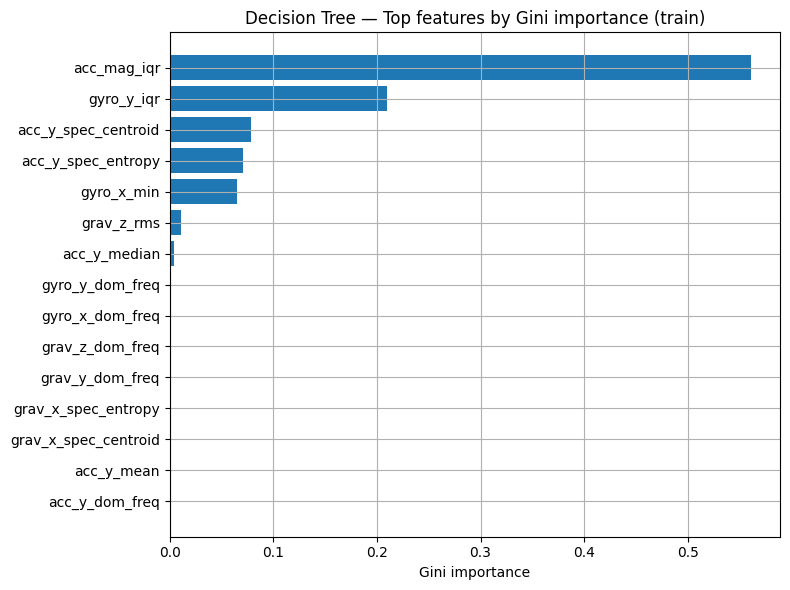

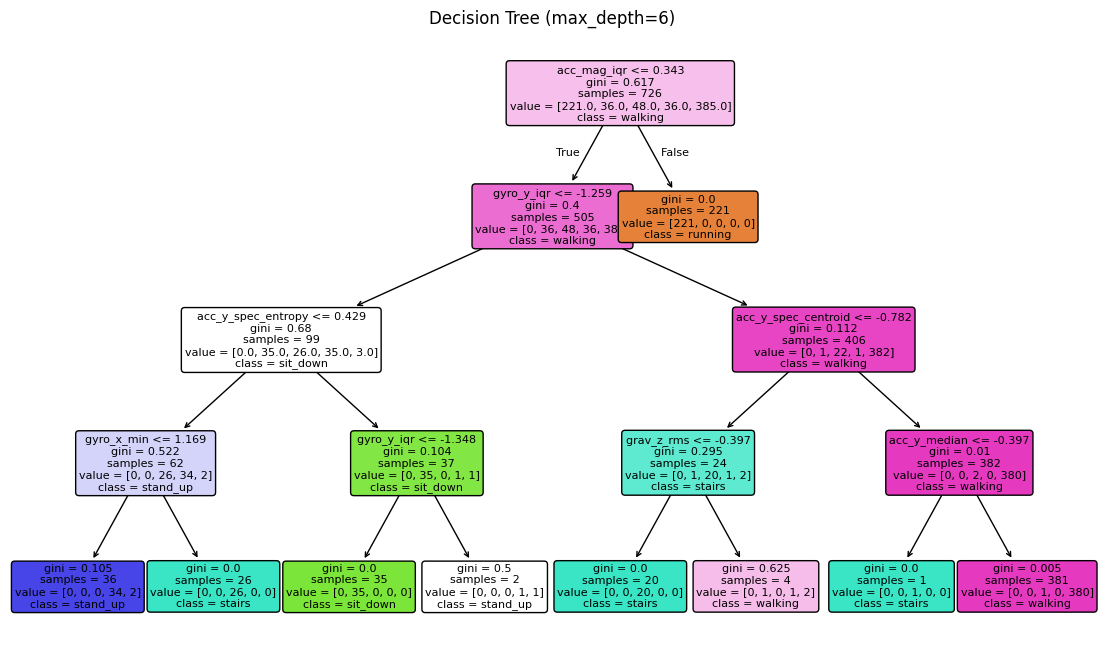

In [120]:
# Decision Tree — train-set evaluation 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import tree as sktree

# 1) Normalized confusion matrix (rows sum to 1)
ConfusionMatrixDisplay.from_estimator(
    best_dt, X_train_dt, y_train,
    normalize="true", cmap="Blues", values_format=".2f"
)
plt.title("Decision Tree — Normalized Confusion Matrix (train)")
plt.show()

# 2) Gini importances + bar plot
dt = best_dt.named_steps["clf"] if hasattr(best_dt, "named_steps") else best_dt
feature_names = list(getattr(X_train_dt, "columns", [f"f{i}" for i in range(dt.n_features_in_)]))
imp = pd.Series(dt.feature_importances_, index=feature_names).sort_values(ascending=False)

# bar plot of top 15
top = imp.head(15).sort_values(ascending=True)
plt.figure(figsize=(8,6))
plt.barh(top.index, top.values)
plt.xlabel("Gini importance")
plt.title("Decision Tree — Top features by Gini importance (train)")
plt.tight_layout()
plt.show()

# 3) Visualize the tree 
# Tree size was confirmed to be 6 which is not too deep to visualize.
# If you wish to visualize more or less levels change max_depth
plt.figure(figsize=(14, 8))
sktree.plot_tree(
    dt,
    feature_names=feature_names,
    class_names=[str(c) for c in dt.classes_],
    max_depth=6, filled=True, rounded=True, fontsize=8
)
plt.title("Decision Tree (max_depth=6)")
plt.show()



In [121]:
# CELL 4 — Naive Bayes (Gaussian)
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

param_grid_gnb = {
    "var_smoothing": np.logspace(-12, -6, 7)  # 1e-12 ... 1e-6
}

gs_gnb = GridSearchCV(
    estimator=gnb,
    param_grid=param_grid_gnb,
    scoring=scorers,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_gnb.fit(X_train_nb, y_train)
summarize_grid_search(gs_gnb)

best_gnb = gs_gnb.best_estimator_

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best params: {'var_smoothing': np.float64(1e-12)}
Refit scorer: kappa
Best CV score (refit metric): 0.9775985025024756
{'mean_accuracy': np.float64(0.9862257912139821), 'mean_kappa': np.float64(0.9775985025024756), 'mean_f1_macro': np.float64(0.9639832730487761)}


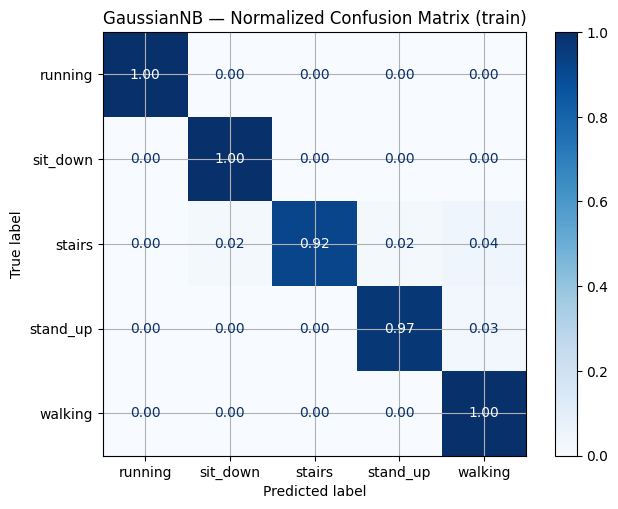

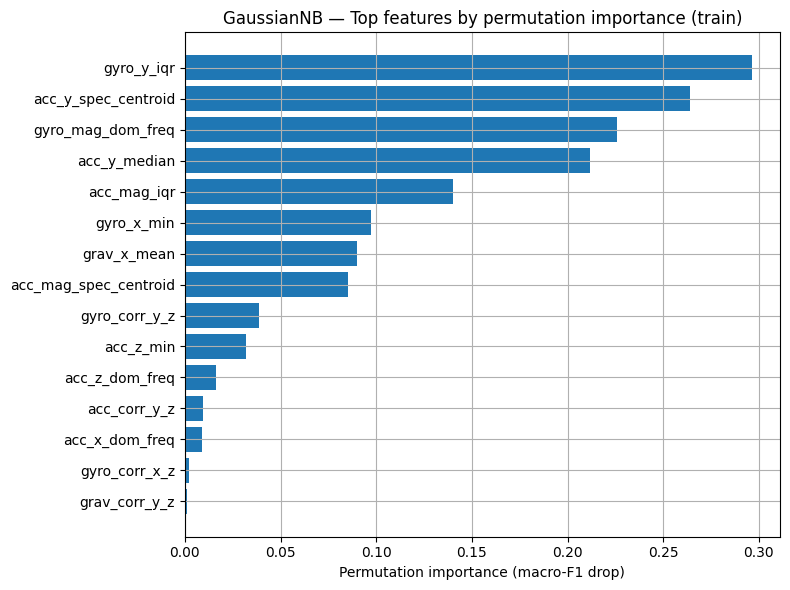

In [122]:
# Gaussian Naive Bayes — train-set evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# 1) Normalized confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_gnb, X_train_nb, y_train,
    normalize="true", cmap="Blues", values_format=".2f"
)
plt.title("GaussianNB — Normalized Confusion Matrix (train)")
plt.show()

# 2) Permutation importance (macro-F1) on train set
result = permutation_importance(
    best_gnb, X_train_nb, y_train,
    n_repeats=20, random_state=42, n_jobs=-1,
    scoring="f1_macro"
)

pi_mean = pd.Series(result.importances_mean, index=list(getattr(X_train_nb, "columns", None)))
pi_std  = pd.Series(result.importances_std,  index=list(getattr(X_train_nb, "columns", None)))
pi_df = (pd.DataFrame({"importance_mean": pi_mean, "importance_std": pi_std})
           .sort_values("importance_mean", ascending=False))

# bar plot of top 15
top = pi_df.head(15).sort_values("importance_mean", ascending=True)
plt.figure(figsize=(8,6))
plt.barh(top.index, top["importance_mean"])
plt.xlabel("Permutation importance (macro-F1 drop)")
plt.title("GaussianNB — Top features by permutation importance (train)")
plt.tight_layout()
plt.show()


In [123]:
# CELL 5 — KNN
from sklearn.neighbors import KNeighborsClassifier

pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])

param_grid_knn = {
    "clf__n_neighbors": list(range(1, 36, 2)),
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],  # 1=Manhattan, 2=Euclidean
}

gs_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    scoring=scorers,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_knn.fit(X_train_knn, y_train)
summarize_grid_search(gs_knn)

best_knn = gs_knn.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'clf__n_neighbors': 1, 'clf__p': 1, 'clf__weights': 'uniform'}
Refit scorer: kappa
Best CV score (refit metric): 0.9932854895134866
{'mean_accuracy': np.float64(0.9958715162966463), 'mean_kappa': np.float64(0.9932854895134866), 'mean_f1_macro': np.float64(0.9876366723259762)}


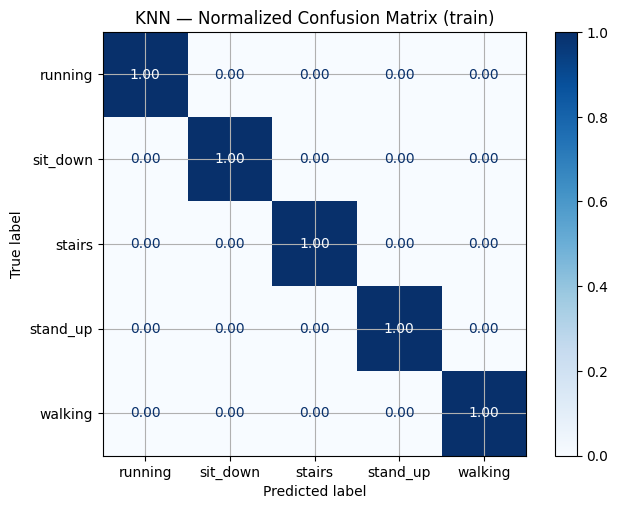

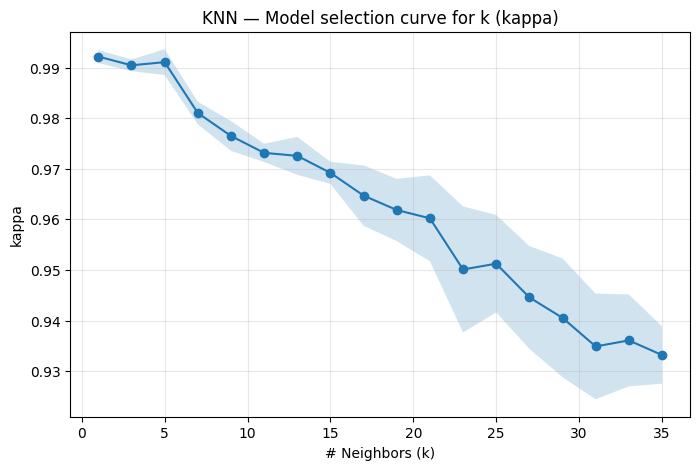

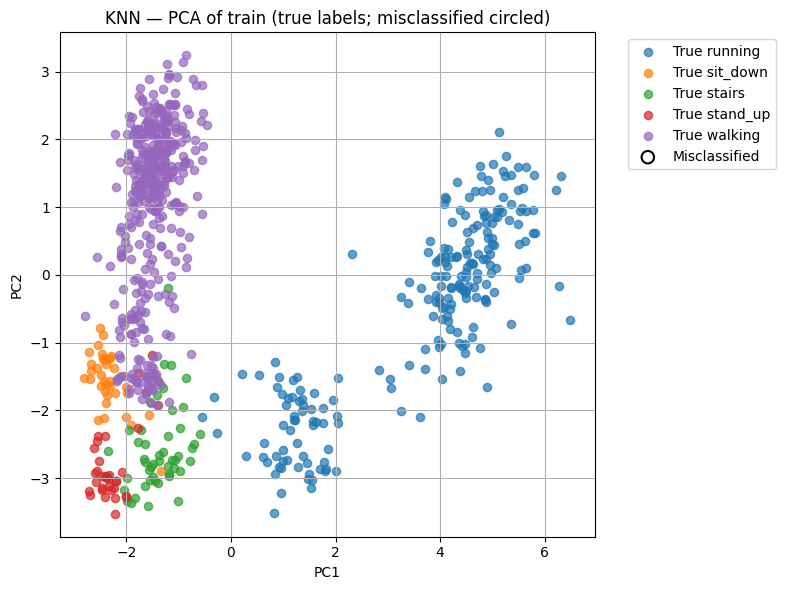

Misclassified on train: 0/726 (0.00%)


In [128]:
# KNN — train-set evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# 1) Normalized confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_knn, X_train_knn, y_train,
    normalize="true", cmap="Blues", values_format=".2f"
)
plt.title("KNN — Normalized Confusion Matrix (train)")
plt.show()

# 2) Model selection curve for n_neighbors using the refit metric
cvres = pd.DataFrame(gs_knn.cv_results_)
metric = gs_knn.refit  # e.g., "kappa" or "f1_macro"
col = f"mean_test_{metric}"
nn_col = "param_clf__n_neighbors"

curve = (cvres
         .assign(n_neighbors=cvres[nn_col].astype(int))
         .groupby("n_neighbors")[col]
         .agg(["mean", "std"])
         .sort_index())

plt.figure(figsize=(8,5))
plt.plot(curve.index, curve["mean"], marker="o")
plt.fill_between(curve.index, curve["mean"]-curve["std"], curve["mean"]+curve["std"], alpha=0.2)
plt.xlabel("# Neighbors (k)")
plt.ylabel(metric)
plt.title(f"KNN — Model selection curve for k ({metric})")
plt.grid(True, alpha=0.3)
plt.show()

# 3) PCA (2D): true labels vs predicted; misclassified circled
pipe = best_knn  # Pipeline(scaler + KNN)
X_scaled = pipe.named_steps["scaler"].transform(X_train_knn)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

y_pred = pipe.predict(X_train_knn)

unique = np.unique(y_train)
colors = plt.get_cmap("tab10").colors
color_map = {cls: colors[i % len(colors)] for i, cls in enumerate(unique)}

plt.figure(figsize=(8,6))
for i, cls in enumerate(unique):
    mask = (y_train == cls)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=35, alpha=0.7, c=[color_map[cls]], label=f"True {cls}")

mis = (y_pred != y_train)
plt.scatter(X_pca[mis, 0], X_pca[mis, 1], s=80, facecolors="none", edgecolors="k",
            linewidths=1.5, label="Misclassified")

plt.title("KNN — PCA of train (true labels; misclassified circled)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

n_mis = int(mis.sum())
print(f"Misclassified on train: {n_mis}/{len(y_train)} ({n_mis/len(y_train):.2%})")


## Unsupervised Learning Methods

In all unsupervised models, a wrapper method is first applied to iterate over candidate feature subsets. The subset selected through this process is then used to train the unsupervised models. The results are as follows:

Convert Class Labels to Integers:

In [125]:
from sklearn.preprocessing import LabelEncoder

# Encode labels to integers for metrics
le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_test_num = le.transform(y_test)

### K-Means Clustering

K-Means Wrapper Feature Subset Selection: Here we select a subset of the features that are suited for K-Means Clustering.

Step 1 | +gyro_z_dom_freq | acc_train=0.807 | acc_test=0.829
Step 2 | +acc_mag_iqr | acc_train=0.810 | acc_test=0.834
Step 3 | +acc_mag_spec_centroid | acc_train=0.835 | acc_test=0.845
Step 4 | +acc_x_dom_freq | acc_train=0.843 | acc_test=0.862
Step 5 | +acc_y_spec_centroid | acc_train=0.872 | acc_test=0.890
Step 6 | +acc_y_dom_freq | acc_train=0.875 | acc_test=0.890
Step 7 | +acc_y_spec_entropy | acc_train=0.880 | acc_test=0.878
Step 8 | +acc_corr_y_z | acc_train=0.884 | acc_test=0.890
Step 9 | +acc_y_median | acc_train=0.891 | acc_test=0.895
Step 10 | +gyro_y_dom_freq | acc_train=0.894 | acc_test=0.895
Step 11 | +gyro_y_iqr | acc_train=0.894 | acc_test=0.901
Step 12 | +acc_mag_dom_freq | acc_train=0.851 | acc_test=0.851
Step 13 | +grav_x_spec_entropy | acc_train=0.858 | acc_test=0.862
Step 14 | +gyro_corr_y_z | acc_train=0.862 | acc_test=0.867
Step 15 | +gyro_x_dom_freq | acc_train=0.865 | acc_test=0.873
Best subset: ['gyro_z_dom_freq', 'acc_mag_iqr', 'acc_mag_spec_centroid', 'acc_x_

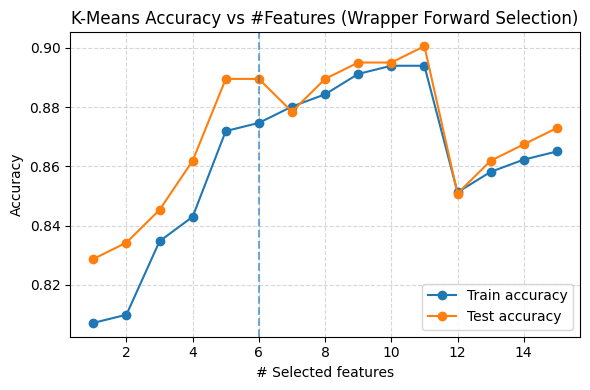

In [126]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

def cluster_accuracy(y_true, y_pred):
    """Accuracy after optimal cluster↔class matching (Hungarian)."""
    n = max(len(np.unique(y_true)), len(np.unique(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n))
    r, c = linear_sum_assignment(cm.max() - cm)
    return cm[r, c].sum() / cm.sum()

def wrapper_kmeans_accuracy(X_train,
                            y_train,
                            X_test=None,
                            y_test=None,
                            *,
                            k=None,
                            n_features_to_select=15,
                            mode="fixed",          # "fixed" -> run full; "auto" -> early stop on no-improve
                            random_state=31,
                            kmeans_kwargs=None,
                            select_set=6):
    """
    Forward selection for K-Means scored by TRAIN accuracy (Hungarian).
    Runs up to n_features_to_select (or available features). Ignores `select_set`
    during the search; at the end returns the subset at that step size.

    Returns:
      X_train_best, X_test_best, chosen_features, chosen_acc_train, history
    """
    if k is None:
        k = len(np.unique(y_train))
    if kmeans_kwargs is None:
        kmeans_kwargs = {}

    features  = list(X_train.columns)
    max_steps = min(n_features_to_select, len(features))

    selected = []
    history  = []   # each: {"step", "feature_added", "acc_train", "acc_test"}

    # forward selection
    for step in range(1, max_steps + 1):
        trial_scores = []  # (acc_train, feature, acc_test)

        for f in features:
            if f in selected:
                continue

            subset = selected + [f]
            km = KMeans(n_clusters=k, random_state=random_state, **kmeans_kwargs)

            labels_tr = km.fit_predict(X_train[subset])
            acc_tr    = cluster_accuracy(y_train, labels_tr)

            acc_te = None
            if X_test is not None and y_test is not None:
                labels_te = km.predict(X_test[subset])
                acc_te    = cluster_accuracy(y_test, labels_te)

            trial_scores.append((acc_tr, f, acc_te))

        if not trial_scores:
            break

        # pick feature that maximizes TRAIN accuracy this step
        trial_scores.sort(key=lambda t: t[0], reverse=True)
        acc_tr, best_f, acc_te = trial_scores[0]
        selected.append(best_f)

        history.append({
            "step": step,
            "feature_added": best_f,
            "acc_train": float(acc_tr),
            "acc_test": None if acc_te is None else float(acc_te),
        })

        print(f"Step {step} | +{best_f} | acc_train={acc_tr:.3f}"
              + (f" | acc_test={acc_te:.3f}" if acc_te is not None else ""))

        # optional early stop if user asked for "auto"
        if mode == "auto":
            prev = history[-2]["acc_train"] if len(history) > 1 else -np.inf
            if acc_tr <= prev:
                print("No improvement on train; early stop.")
                break

    # ----- choose subset to RETURN -----
    if isinstance(select_set, int) and select_set > 0:
        chosen_step = min(select_set, len(history))
    else:
        # default: best TRAIN accuracy step
        chosen_step = int(np.argmax([h["acc_train"] for h in history])) + 1

    chosen_features  = [h["feature_added"] for h in history][:chosen_step]
    chosen_acc_train = history[chosen_step - 1]["acc_train"]

    X_train_best = X_train[chosen_features]
    X_test_best  = None if X_test is None else X_test[chosen_features]

    return X_train_best, X_test_best, chosen_features, float(chosen_acc_train), history



#///////////////////////////////////////////////////////////////////////////////////////

X_train_km_best, X_test_km_best, subset, best_acc, hist = wrapper_kmeans_accuracy(X_train_fs, 
                                                                                  y_train_num, 
                                                                                  X_test_fs, 
                                                                                  y_test_num,
                                                                                  k=5,
                                                                                  n_features_to_select=15,
                                                                                  mode="fixed",          # or "fixed"
                                                                                  random_state=31,
                                                                                  kmeans_kwargs={"n_init": 20, "max_iter": 300, "algorithm": "lloyd"},
                                                                                  select_set=6)

print("Best subset:", subset)
print("Best train accuracy:", best_acc)

# Plot
steps = [h["step"] for h in hist]
acc_train = [h["acc_train"] for h in hist]
acc_test  = [h["acc_test"] for h in hist] if hist[0]["acc_test"] is not None else None

plt.figure(figsize=(6,4))
plt.plot(steps, acc_train, marker='o', label="Train accuracy")
if acc_test is not None:
    plt.plot(steps, acc_test, marker='o', label="Test accuracy")
sel = len(subset)   # equals chosen_step
plt.axvline(sel, linestyle="--", alpha=0.6)
plt.xlabel("# Selected features")
plt.ylabel("Accuracy")
plt.title("K-Means Accuracy vs #Features (Wrapper Forward Selection)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Using the reduced subset of features we train the K-Means Clustering Model


Train Accuracies for k=1..5: {1: 0.5303030303030303, 2: 0.8154269972451791, 3: 0.859504132231405, 4: 0.849862258953168, 5: 0.8746556473829201}

K-Means (k=5) - TRAIN Results:
  Accuracy: 0.8747
  F1 Score: 0.6230
  Kappa:    0.7940

K-Means (k=5) - TEST Results:
  Accuracy: 0.8895
  F1 Score: 0.6402
  Kappa:    0.8152


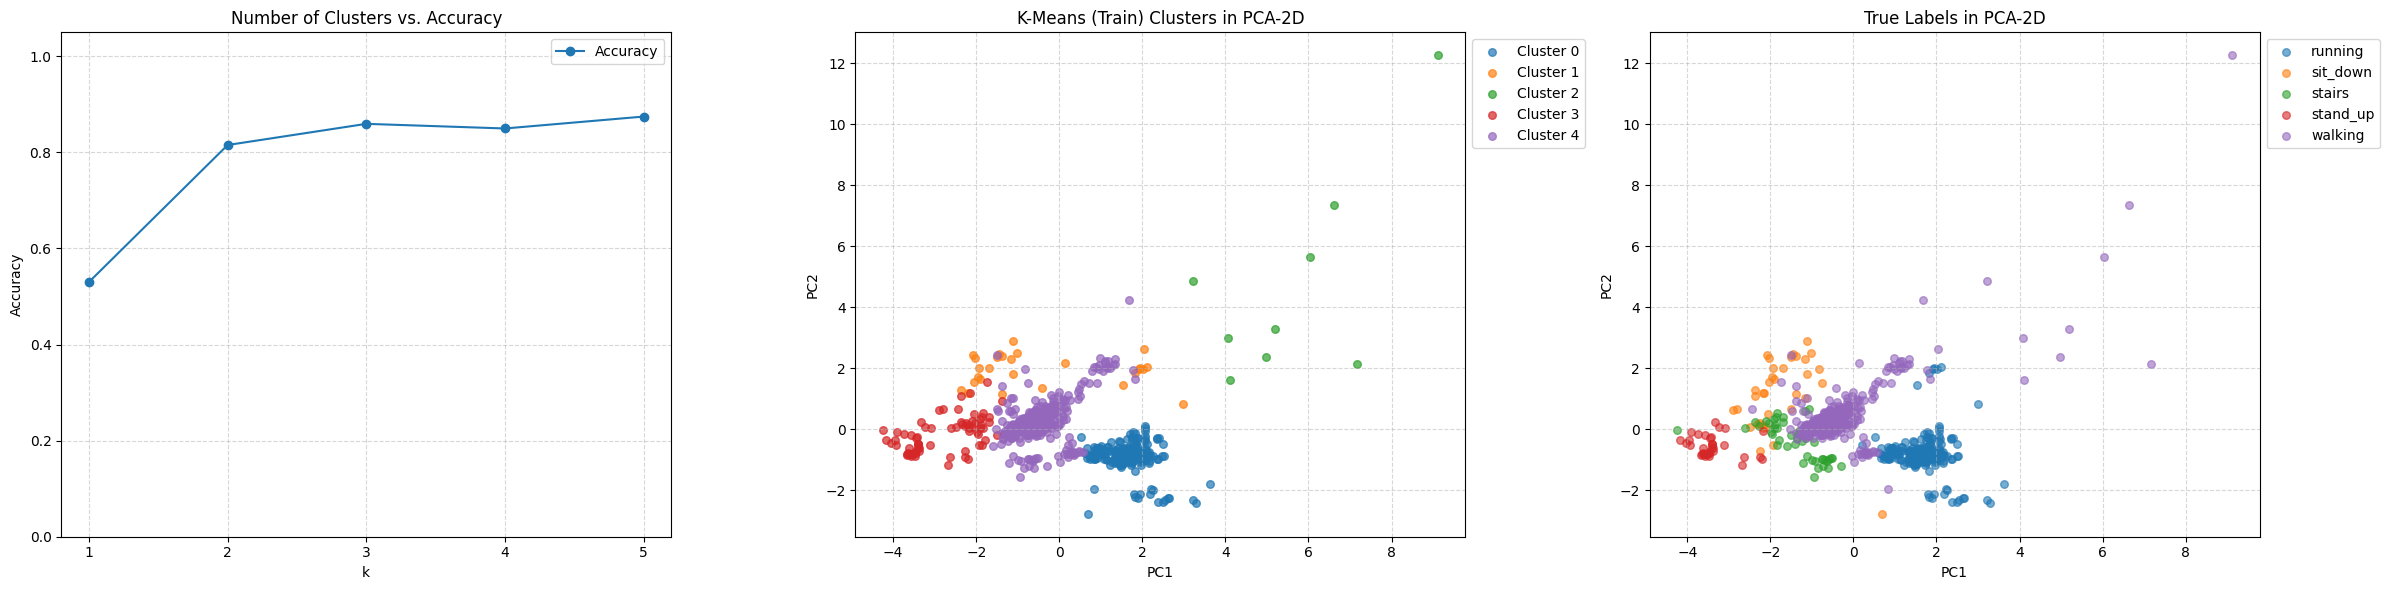

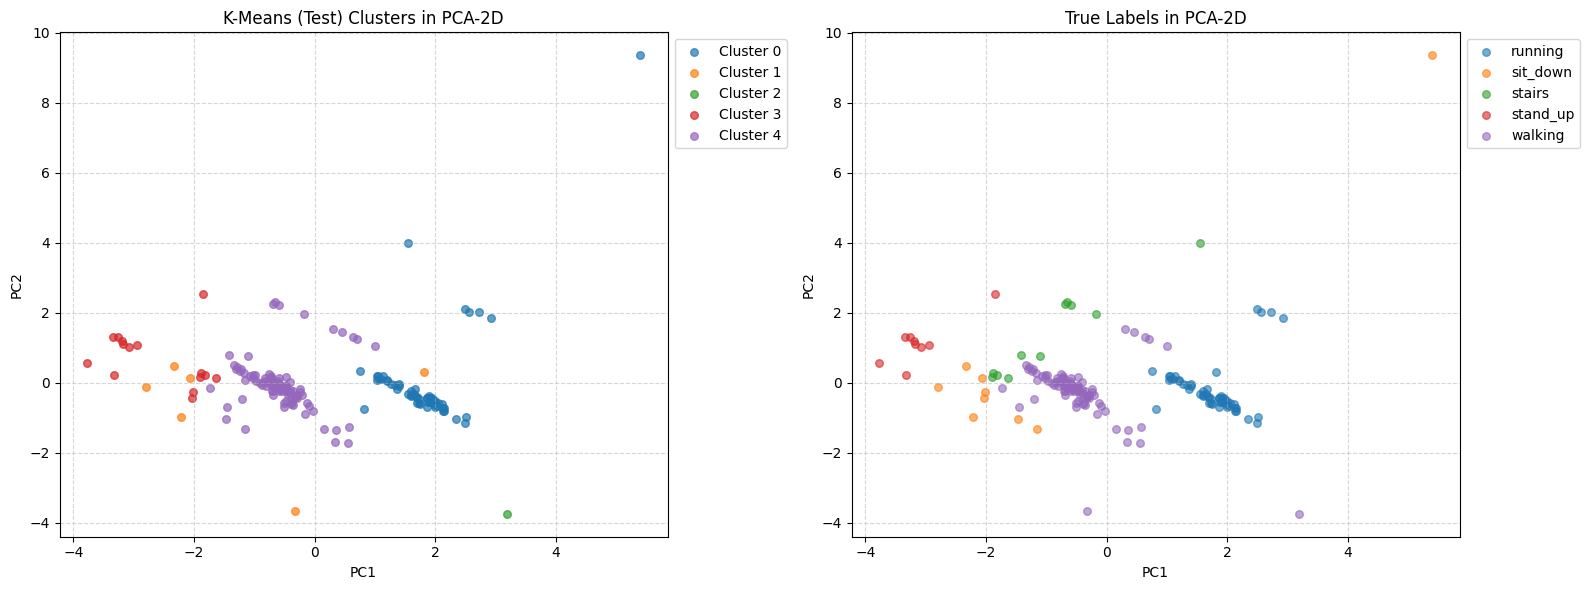

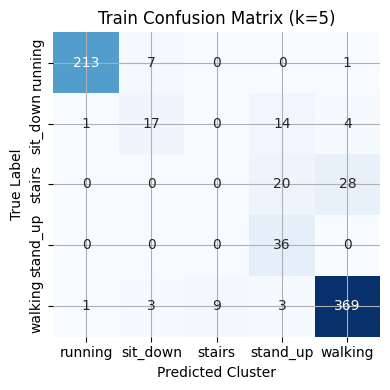

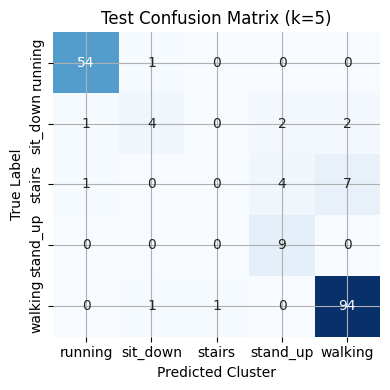

In [129]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

def align_clusters(y_true, y_pred):
    """
    Align raw cluster IDs to ground-truth class IDs using Hungarian algorithm.
    """
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)      # maximize matches
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping[c] for c in y_pred])


def eval_model(name, y_true, y_pred):
    """
    Print and return Accuracy, F1-macro and Cohen's Kappa.
    """
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    kappa = cohen_kappa_score(y_true, y_pred)

    print(f"\n{name} Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  Kappa:    {kappa:.4f}")
    return acc, f1, kappa


def plot_clustering_results(model_name, X_data, y_true, le,
                            cluster_range, accuracies, clusters_k,
                            show_k_vs_acc=True):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_data)

    # If we don't want the first plot, make only 2 subplots
    n_cols = 3 if show_k_vs_acc else 2
    fig, axs = plt.subplots(1, n_cols, figsize=(8*n_cols, 6))

    idx = 0
    # --- 1) k vs Accuracy ---
    if show_k_vs_acc:
        axs[0].plot(list(cluster_range), accuracies, marker='o', label="Accuracy")
        axs[0].set_title("Number of Clusters vs. Accuracy")
        axs[0].set_xlabel("k")
        axs[0].set_ylabel("Accuracy")
        axs[0].set_xticks(list(cluster_range))
        axs[0].set_ylim(0, 1.05)
        axs[0].grid(True, linestyle='--', alpha=0.5)
        axs[0].legend()
        idx = 1

    # --- 2) Cluster assignments in PCA space ---
    for c in np.unique(clusters_k):
        pts = X_pca[clusters_k == c]
        axs[idx].scatter(pts[:, 0], pts[:, 1], label=f"Cluster {c}", alpha=0.7, s=30)
    axs[idx].set_title(f"{model_name} Clusters in PCA-2D")
    axs[idx].set_xlabel("PC1")
    axs[idx].set_ylabel("PC2")
    axs[idx].legend(loc='upper left', bbox_to_anchor=(1, 1))
    axs[idx].grid(True, linestyle='--', alpha=0.5)

    # --- 3) True labels in PCA space ---
    for lab in np.unique(y_true):
        pts = X_pca[y_true == lab]
        name = str(le.inverse_transform([lab])[0]) if hasattr(le, "inverse_transform") else f"Class {lab}"
        axs[idx+1].scatter(pts[:, 0], pts[:, 1], label=name, alpha=0.6, s=30)
    axs[idx+1].set_title("True Labels in PCA-2D")
    axs[idx+1].set_xlabel("PC1")
    axs[idx+1].set_ylabel("PC2")
    axs[idx+1].legend(loc='upper left', bbox_to_anchor=(1, 1))
    axs[idx+1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, le, title, cmap='Blues'):
    """
    Pretty confusion matrix plot.
    """
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
    plt.xlabel("Predicted Cluster")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# KMeans for k = 1..5 on TRAIN
cluster_range = range(1, 6)
kmeans_results = []

for k in cluster_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = km.fit_predict(X_train_km_best)
    kmeans_results.append(clusters)

# Compute train accuracies for each k
accuracies = []
for clusters in kmeans_results:
    aligned = align_clusters(y_train_num, clusters)
    accuracies.append(accuracy_score(y_train_num, aligned))

print("\nTrain Accuracies for k=1..5:", dict(zip(cluster_range, accuracies)))

# Pick k = 5 (final model), evaluate on TRAIN
k_final = 5
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters_train = km_final.fit_predict(X_train_km_best)
y_train_aligned = align_clusters(y_train_num, clusters_train)

acc_train, f1_train, kappa_train = eval_model("K-Means (k=5) - TRAIN", y_train_num, y_train_aligned)

# Predict & evaluate on TEST
clusters_test = km_final.predict(X_test_km_best)
y_test_aligned = align_clusters(y_test_num, clusters_test)

acc_test, f1_test, kappa_test = eval_model("K-Means (k=5) - TEST", y_test_num, y_test_aligned)

# plots
plot_clustering_results("K-Means (Train)",
                        X_train_km_best, y_train_num, le,
                        cluster_range, accuracies, y_train_aligned,
                        show_k_vs_acc=True)

plot_clustering_results("K-Means (Test)",
                        X_test_km_best, y_test_num, le,
                        [5], [acc_test], y_test_aligned,
                        show_k_vs_acc=False)


# Confusion Matrices
cm_train = confusion_matrix(y_train_num, y_train_aligned)
plot_confusion_matrix(cm_train, le, "Train Confusion Matrix (k=5)", cmap='Blues')

cm_test = confusion_matrix(y_test_num, y_test_aligned)
plot_confusion_matrix(cm_test, le, "Test Confusion Matrix (k=5)", cmap='Blues')


### Fuzzy C-Means Clustering

Fuzzy C-Means Wrapper Feature Subset Selection: Here we select a subset of the features that are suited for Fuzzy C-Means Clustering.

Step 1 | +gyro_z_dom_freq | acc_train=0.807 | acc_test=0.829
Step 2 | +gyro_corr_y_z | acc_train=0.796 | acc_test=0.818
Step 3 | +acc_x_dom_freq | acc_train=0.807 | acc_test=0.834
Step 4 | +acc_mag_spec_centroid | acc_train=0.825 | acc_test=0.862
Step 5 | +acc_mag_iqr | acc_train=0.831 | acc_test=0.856
Step 6 | +acc_x_iqr | acc_train=0.751 | acc_test=0.785
Step 7 | +grav_z_rms | acc_train=0.759 | acc_test=0.796
Step 8 | +gyro_z_kurtosis | acc_train=0.762 | acc_test=0.801
Step 9 | +acc_y_mean | acc_train=0.760 | acc_test=0.796
Step 10 | +acc_z_min | acc_train=0.763 | acc_test=0.790
Step 11 | +gyro_z_spec_centroid | acc_train=0.759 | acc_test=0.785
Step 12 | +gyro_mag_spec_centroid | acc_train=0.769 | acc_test=0.801
Step 13 | +gyro_y_iqr | acc_train=0.771 | acc_test=0.807
Step 14 | +grav_mag_max | acc_train=0.771 | acc_test=0.807
Step 15 | +acc_y_median | acc_train=0.770 | acc_test=0.807

FCM - Returned subset size: 6
FCM - Returned subset: ['gyro_z_dom_freq', 'gyro_corr_y_z', 'acc_x_dom

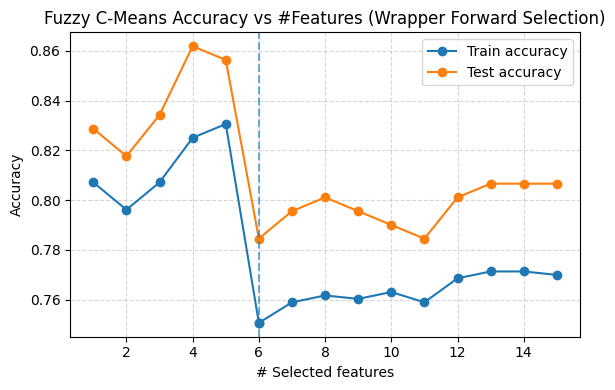

In [131]:
import skfuzzy as fuzz

def _fcm_memberships_from_centers(X, centers, m=2.0, eps=1e-12):
    """
    Compute FCM memberships for X given learned centers (no refit).
    Returns U with shape (c, n_samples).
    """
    X = np.asarray(X)
    C = np.asarray(centers)
    d = np.linalg.norm(X[None, :, :] - C[:, None, :], axis=2) + eps  # (c, n)

    exact = np.isclose(d, eps)
    if exact.any():
        U = np.zeros_like(d)
        closest = np.argmin(d, axis=0)
        U[closest, np.arange(X.shape[0])] = 1.0
        mask = (U.sum(axis=0) == 0)
        if mask.any():
            dm = d[:, mask]
            p = 2.0 / (m - 1.0)
            ratio = (dm[:, None, :] / dm[None, :, :]) ** p
            denom = ratio.sum(axis=1)
            U[:, mask] = 1.0 / denom
        return U

    p = 2.0 / (m - 1.0)
    ratio = (d[:, None, :] / d[None, :, :]) ** p
    denom = ratio.sum(axis=1)
    return 1.0 / denom


def wrapper_fcm_accuracy(X_train,
                         y_train,
                         X_test=None,
                         y_test=None,
                         *,
                         k=5,
                         n_features_to_select=15,
                         mode="fixed",           # "fixed" -> run full; "auto" -> early stop on no-improve
                         m=2.0,
                         error=0.005,
                         maxiter=1000,
                         random_state=None,
                         select_set=None):
    """
    Forward selection for FCM scored by TRAIN accuracy (Hungarian).
    Runs up to n_features_to_select (or available features). Ignores `select_set`
    during the search; at the end returns the subset at that step size.

    Returns:
      X_train_best, X_test_best, best_subset, best_acc_train_at_selected_step, history
    """
    if k is None:
        k = len(np.unique(y_train))

    # RNG for reproducible U0 initializations
    rng = np.random.RandomState(random_state) if random_state is not None else None

    features = list(X_train.columns)
    max_steps = min(n_features_to_select, len(features))

    selected = []
    history  = []  # each item: step, feature_added, acc_train, (optional) acc_test

    # forward selection
    for step in range(1, max_steps + 1):
        trial_scores = []  # (acc_train, feature, acc_test)

        for f in features:
            if f in selected:
                continue
            subset = selected + [f]
            Xtr = X_train[subset].to_numpy().T  # (features, samples)

            # Reproducible random soft membership init U0 if random_state provided
            if rng is not None:
                U0 = rng.rand(k, Xtr.shape[1])
                U0 /= U0.sum(axis=0, keepdims=True)  # columns sum to 1
            else:
                U0 = None

            cntr, Utr, *_ = fuzz.cluster.cmeans(
                Xtr, c=k, m=m, error=error, maxiter=maxiter, init=U0
            )
            labels_tr = Utr.argmax(axis=0)
            acc_tr = cluster_accuracy(y_train, labels_tr)

            acc_te = None
            if X_test is not None and y_test is not None:
                Ute = _fcm_memberships_from_centers(X_test[subset].to_numpy(), cntr, m=m)
                labels_te = Ute.argmax(axis=0)
                acc_te = cluster_accuracy(y_test, labels_te)

            trial_scores.append((acc_tr, f, acc_te))

        # pick feature giving highest TRAIN accuracy this step
        trial_scores.sort(key=lambda t: t[0], reverse=True)
        acc_tr, best_f, acc_te = trial_scores[0]
        selected.append(best_f)
        history.append({
            "step": step,
            "feature_added": best_f,
            "acc_train": float(acc_tr),
            "acc_test": None if acc_te is None else float(acc_te),
        })
        print(f"Step {step} | +{best_f} | acc_train={acc_tr:.3f}"
              + (f" | acc_test={acc_te:.3f}" if acc_te is not None else ""))

        # optional early stop only if user asked for "auto"
        if mode == "auto":
            prev = history[-2]["acc_train"] if len(history) > 1 else -np.inf
            if acc_tr <= prev:
                print("No improvement on train; early stop.")
                break

    # choose subset to RETURN (select_set = integer step)
    if isinstance(select_set, int) and select_set > 0:
        chosen_step = min(select_set, len(history))
    else:
        # if not specified, default to best TRAIN accuracy seen
        chosen_step = int(np.argmax([h["acc_train"] for h in history])) + 1

    chosen_features  = [h["feature_added"] for h in history][:chosen_step]
    chosen_acc_train = history[chosen_step - 1]["acc_train"]

    X_train_best = X_train[chosen_features]
    X_test_best  = None if X_test is None else X_test[chosen_features]
    return X_train_best, X_test_best, chosen_features, float(chosen_acc_train), history


X_train_fcm_best, X_test_fcm_best, subset_fcm, best_acc_fcm, hist_fcm = wrapper_fcm_accuracy(X_train_fs,
                                                                                             y_train_num,
                                                                                             X_test=X_test_fs,
                                                                                             y_test=y_test_num,
                                                                                             k=5,
                                                                                             n_features_to_select=15,
                                                                                             mode="fixed",      # runs the whole search
                                                                                             m=2.0,
                                                                                             error=0.005,
                                                                                             maxiter=1000,
                                                                                             random_state=99,
                                                                                             select_set=6)
print("\nFCM - Returned subset size:", len(subset_fcm))
print("FCM - Returned subset:", subset_fcm)
print("FCM - Train accuracy at that step:", best_acc_fcm)

# Plot: #features vs accuracy from history
steps     = [h["step"] for h in hist_fcm]
acc_train = [h["acc_train"] for h in hist_fcm]
has_test  = (hist_fcm and hist_fcm[0]["acc_test"] is not None)
acc_test  = [h["acc_test"] for h in hist_fcm] if has_test else None

plt.figure(figsize=(6,4))
plt.plot(steps, acc_train, marker='o', label="Train accuracy")
if has_test:
    plt.plot(steps, acc_test, marker='o', label="Test accuracy")
# highlight the selected step
sel = len(subset_fcm)   # equals chosen_step
plt.axvline(sel, linestyle="--", alpha=0.6)
plt.scatter([sel], [acc_train[sel-1]], zorder=3)
plt.xlabel("# Selected features")
plt.ylabel("Accuracy")
plt.title("Fuzzy C-Means Accuracy vs #Features (Wrapper Forward Selection)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Using the reduced subset of features we train the Fuzzy C-Mean Clustering Model


Train Accuracies for k=1..5 (FCM): {1: 0.5303030303030303, 2: 0.8223140495867769, 3: 0.7066115702479339, 4: 0.7424242424242424, 5: 0.7506887052341598}

Fuzzy C-Means (k=5) - TRAIN Results:
  Accuracy: 0.5289
  F1 Score: 0.4392
  Kappa:    0.3937

Fuzzy C-Means (k=5) - TEST Results:
  Accuracy: 0.6077
  F1 Score: 0.4781
  Kappa:    0.4712


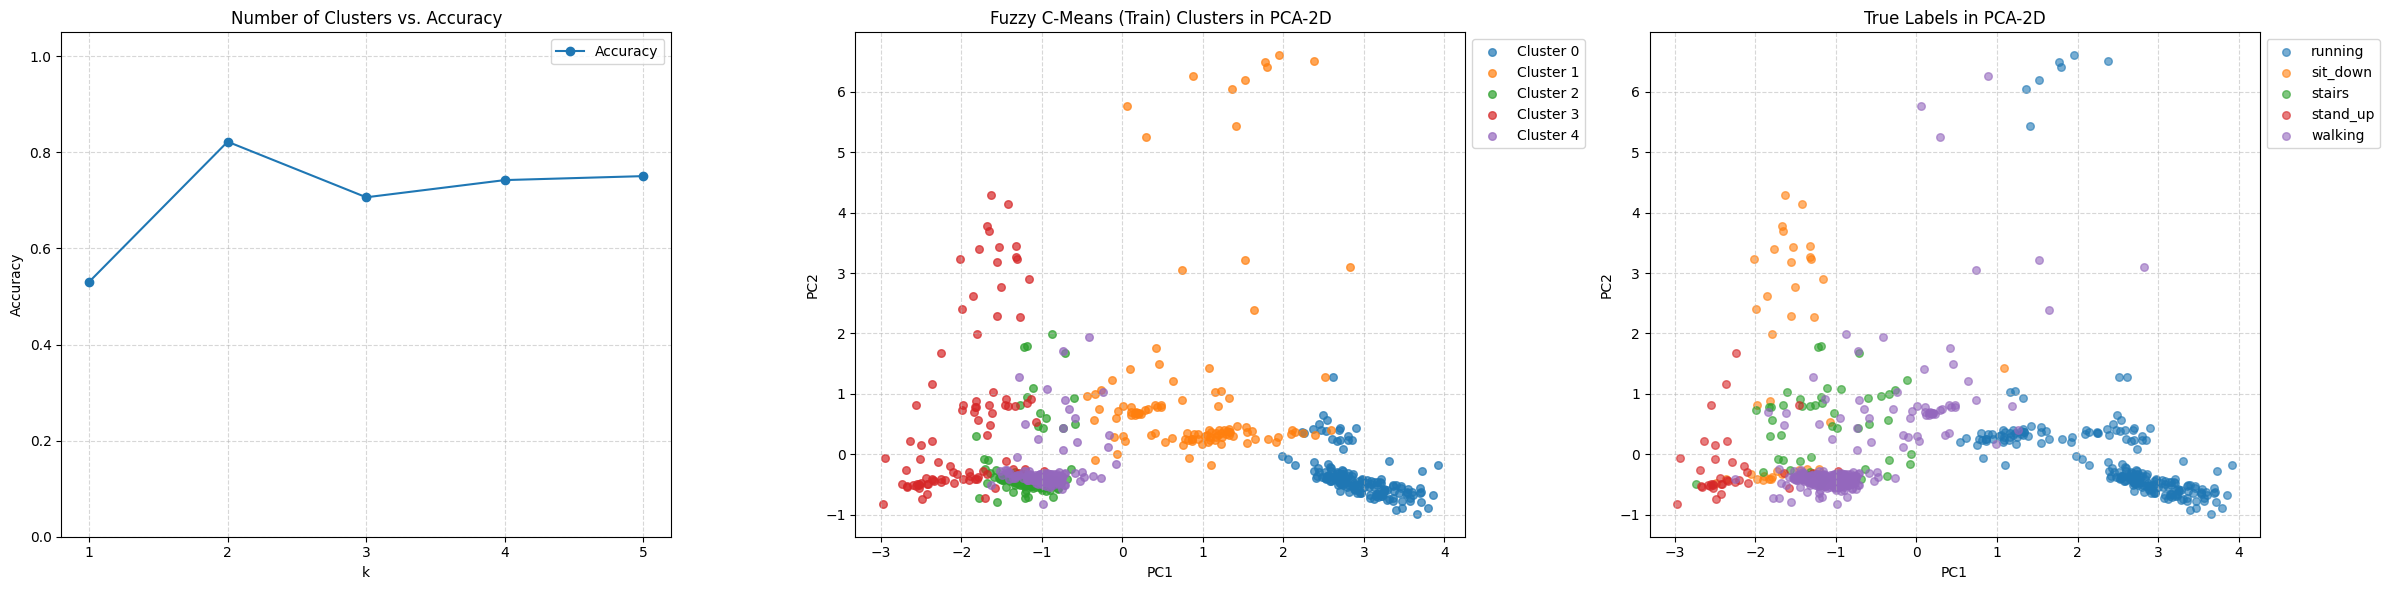

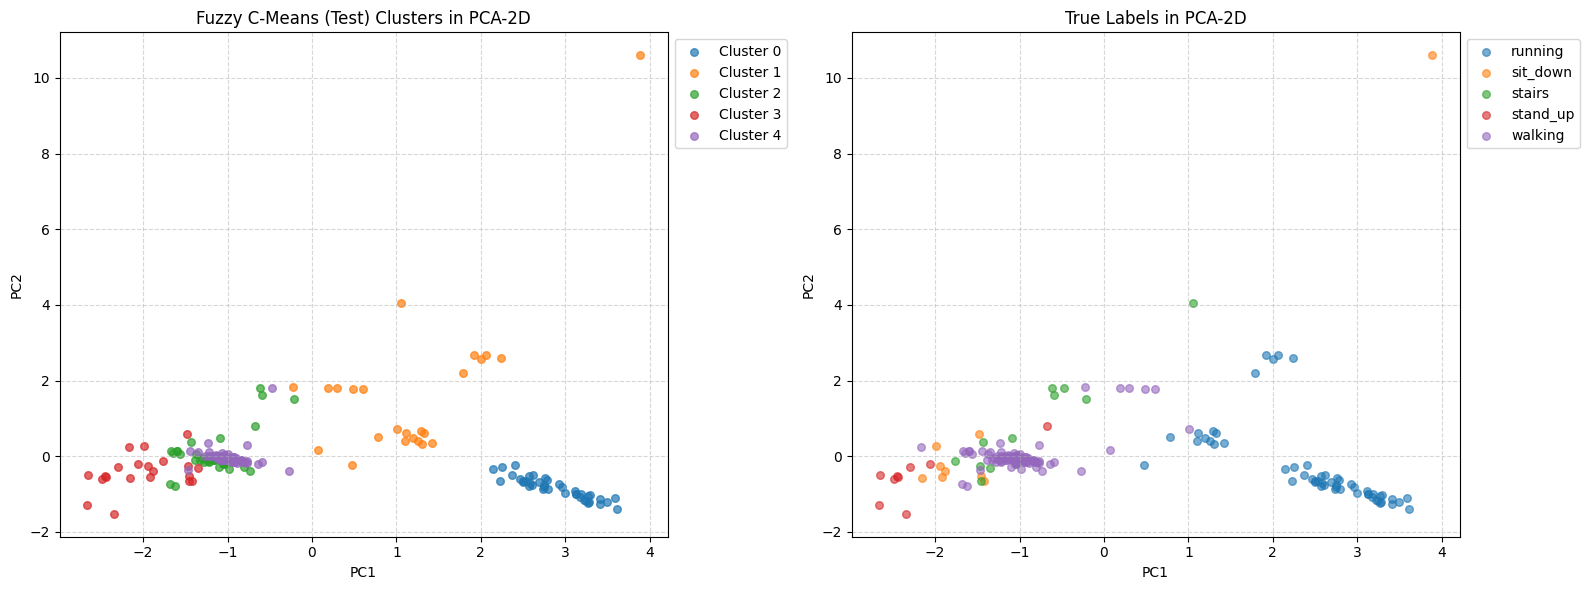

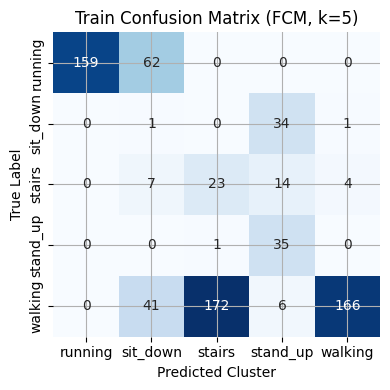

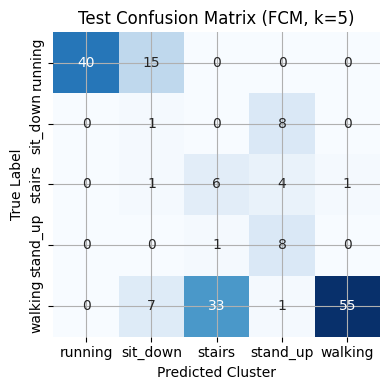

In [132]:
cluster_range = range(1, 6)
fcm_results = []

# Reproducible init for cmeans
rng = np.random.RandomState(42)

for k in cluster_range:
    # skfuzzy.cmeans expects (features, samples)
    Xtr = X_train_fcm_best.to_numpy().T
    # reproducible random membership init U0
    U0 = rng.rand(k, Xtr.shape[1])
    U0 /= U0.sum(axis=0, keepdims=True)

    cntr, Utr, _, _, _, _, _ = fuzz.cluster.cmeans(Xtr, c=k, m=2.0, error=0.005, maxiter=1000, init=U0)
    clusters = Utr.argmax(axis=0)  # hard labels
    fcm_results.append(clusters)

# Train accuracies for each k (after alignment)
accuracies = []
for clusters in fcm_results:
    aligned = align_clusters(y_train_num, clusters)
    accuracies.append(accuracy_score(y_train_num, aligned))

print("\nTrain Accuracies for k=1..5 (FCM):", dict(zip(cluster_range, accuracies)))

# Final k = 5: fit on TRAIN, predict on TEST
k_final = 5

# Fit FCM on train (k=5) with reproducible init
Xtr = X_train_fcm_best.to_numpy().T
U0 = rng.rand(k_final, Xtr.shape[1]); U0 /= U0.sum(axis=0, keepdims=True)
cntr_final, Utr_final, _, _, _, _, _ = fuzz.cluster.cmeans(Xtr, c=k_final, m=2.0, error=0.005, maxiter=1000, init=U0)

clusters_train = Utr_final.argmax(axis=0)
y_train_aligned = align_clusters(y_train_num, clusters_train)
acc_train, f1_train, kappa_train = eval_model("Fuzzy C-Means (k=5) - TRAIN", y_train_num, y_train_aligned)

# Predict clusters for TEST using learned centers
Ute_final = _fcm_memberships_from_centers(X_test_fcm_best.to_numpy(), cntr_final, m=2.0)
clusters_test = Ute_final.argmax(axis=0)
y_test_aligned = align_clusters(y_test_num, clusters_test)
acc_test, f1_test, kappa_test = eval_model("Fuzzy C-Means (k=5) - TEST", y_test_num, y_test_aligned)

# Plot
plot_clustering_results("Fuzzy C-Means (Train)",
                        X_train_fcm_best, y_train_num, le,
                        cluster_range, accuracies, y_train_aligned,
                        show_k_vs_acc=True)

plot_clustering_results("Fuzzy C-Means (Test)",
                        X_test_fcm_best, y_test_num, le,
                        [k_final], [acc_test], y_test_aligned,
                        show_k_vs_acc=False)

# Confusion Matrices
cm_train = confusion_matrix(y_train_num, y_train_aligned)
plot_confusion_matrix(cm_train, le, "Train Confusion Matrix (FCM, k=5)", cmap='Blues')

cm_test = confusion_matrix(y_test_num, y_test_aligned)
plot_confusion_matrix(cm_test, le, "Test Confusion Matrix (FCM, k=5)", cmap='Blues')


### Gaussian Mixture Models (GMMs)

Gaussian Mixture Model Wrapper Feature Subset Selection: Here we select a subset of the features that are suited for GMM.

Step 1 | +gyro_y_dom_freq | acc_train=0.815 | acc_test=0.829
Step 2 | +acc_y_spec_centroid | acc_train=0.825 | acc_test=0.829
Step 3 | +acc_corr_y_z | acc_train=0.839 | acc_test=0.867
Step 4 | +acc_y_spec_entropy | acc_train=0.850 | acc_test=0.878
Step 5 | +gyro_y_iqr | acc_train=0.862 | acc_test=0.890
Step 6 | +gyro_x_min | acc_train=0.847 | acc_test=0.878
Step 7 | +acc_mag_dom_freq | acc_train=0.851 | acc_test=0.878
Step 8 | +gyro_x_dom_freq | acc_train=0.848 | acc_test=0.873
Step 9 | +grav_z_dom_freq | acc_train=0.855 | acc_test=0.873
Step 10 | +acc_z_min | acc_train=0.854 | acc_test=0.873
Step 11 | +grav_x_spec_centroid | acc_train=0.857 | acc_test=0.890
Step 12 | +acc_y_dom_freq | acc_train=0.817 | acc_test=0.845
Step 13 | +grav_x_dom_freq | acc_train=0.828 | acc_test=0.851
Step 14 | +acc_mag_spec_centroid | acc_train=0.833 | acc_test=0.851
Step 15 | +acc_z_dom_freq | acc_train=0.854 | acc_test=0.878

GMM - Returned subset size: 6
GMM - Returned subset: ['gyro_y_dom_freq', 'acc_y_

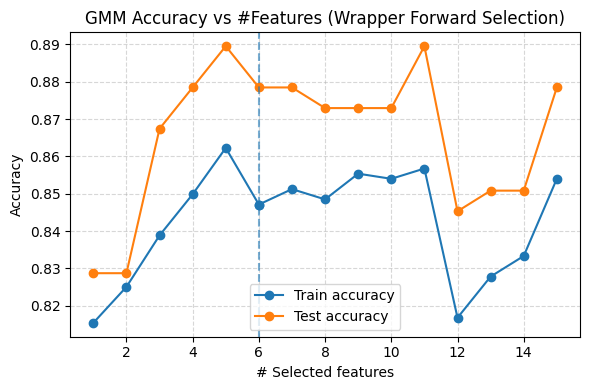

In [133]:
from sklearn.mixture import GaussianMixture

def wrapper_gmm_accuracy(X_train,
                         y_train,
                         X_test=None,
                         y_test=None,
                         *,
                         k=5,
                         n_features_to_select=15,
                         mode="fixed",              # "fixed" -> run full; "auto" -> early stop on no-improve
                         random_state=42,
                         select_set=6,           # INT: subset size to RETURN at the end (e.g., 6)
                         gmm_kwargs=None):
    """
    Forward selection for Gaussian Mixture Models scored by TRAIN accuracy (Hungarian).
    Runs up to n_features_to_select (or available features). Ignores `select_set`
    during the search; at the end returns the subset at that step size.

    Returns:
      X_train_best, X_test_best, chosen_features, chosen_acc_train, history
    """
    if k is None:
        k = len(np.unique(y_train))
    if gmm_kwargs is None:
        gmm_kwargs = {}
    features  = list(X_train.columns)
    max_steps = min(n_features_to_select, len(features))
    selected = []
    history  = []   # each item: {"step", "feature_added", "acc_train", "acc_test"}

    # forward selection
    for step in range(1, max_steps + 1):
        trial_scores = []  # (acc_train, feature, acc_test)
        for f in features:
            if f in selected:
                continue
            subset = selected + [f]
            gmm = GaussianMixture(n_components=k, random_state=random_state, **gmm_kwargs)
            # Fit on train subset; labels = argmax posterior (predict)
            gmm.fit(X_train[subset])
            labels_tr = gmm.predict(X_train[subset])
            acc_tr    = cluster_accuracy(y_train, labels_tr)
            acc_te = None
            if X_test is not None and y_test is not None:
                labels_te = gmm.predict(X_test[subset])
                acc_te    = cluster_accuracy(y_test, labels_te)
            trial_scores.append((acc_tr, f, acc_te))
        if not trial_scores:
            break
        # pick feature that maximizes TRAIN accuracy this step
        trial_scores.sort(key=lambda t: t[0], reverse=True)
        acc_tr, best_f, acc_te = trial_scores[0]
        selected.append(best_f)
        history.append({
            "step": step,
            "feature_added": best_f,
            "acc_train": float(acc_tr),
            "acc_test": None if acc_te is None else float(acc_te)})
        print(f"Step {step} | +{best_f} | acc_train={acc_tr:.3f}"
              + (f" | acc_test={acc_te:.3f}" if acc_te is not None else ""))
        # optional early stop if user asked for "auto"
        if mode == "auto":
            prev = history[-2]["acc_train"] if len(history) > 1 else -np.inf
            if acc_tr <= prev:
                print("No improvement on train; early stop.")
                break
    if isinstance(select_set, int) and select_set > 0:
        chosen_step = min(select_set, len(history))
    else:
        # default: best TRAIN accuracy step
        chosen_step = int(np.argmax([h["acc_train"] for h in history])) + 1

    chosen_features  = [h["feature_added"] for h in history][:chosen_step]
    chosen_acc_train = history[chosen_step - 1]["acc_train"]
    X_train_best = X_train[chosen_features]
    X_test_best  = None if X_test is None else X_test[chosen_features]
    return X_train_best, X_test_best, chosen_features, float(chosen_acc_train), history


X_train_gmm_best, X_test_gmm_best, subset_gmm, best_acc_gmm, hist_gmm = wrapper_gmm_accuracy(X_train_fs,
                                                                                             y_train_num,
                                                                                             X_test=X_test_fs,
                                                                                             y_test=y_test_num,
                                                                                             k=5,
                                                                                             n_features_to_select=15,
                                                                                             mode="fixed",
                                                                                             random_state=1,
                                                                                             select_set=6,           # <- return the subset at step 6
                                                                                             gmm_kwargs={"covariance_type": "full",
                                                                                                         "n_init": 1,                
                                                                                                         "reg_covar": 1e-6})
print("\nGMM - Returned subset size:", len(subset_gmm))
print("GMM - Returned subset:", subset_gmm)
print("GMM - Train accuracy at that step:", best_acc_gmm)

# Plot: #features vs accuracy from history
steps     = [h["step"] for h in hist_gmm]
acc_train = [h["acc_train"] for h in hist_gmm]
has_test  = (hist_gmm and hist_gmm[0]["acc_test"] is not None)
acc_test  = [h["acc_test"] for h in hist_gmm] if has_test else None

plt.figure(figsize=(6,4))
plt.plot(steps, acc_train, marker='o', label="Train accuracy")
if has_test:
    plt.plot(steps, acc_test, marker='o', label="Test accuracy")
# highlight the selected step
sel = len(subset_gmm)   # equals chosen_step
plt.axvline(sel, linestyle="--", alpha=0.6)
plt.scatter([sel], [acc_train[sel-1]], zorder=3)
plt.xlabel("# Selected features")
plt.ylabel("Accuracy")
plt.title("GMM Accuracy vs #Features (Wrapper Forward Selection)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Using the reduced subset of features we train the GMM Clustering Model


Train Accuracies for k=1..5 (GMM): {1: 0.5303030303030303, 2: 0.5068870523415978, 3: 0.8126721763085399, 4: 0.756198347107438, 5: 0.7617079889807162}

GMM (k=5) - TRAIN Results:
  Accuracy: 0.7534
  F1 Score: 0.5640
  Kappa:    0.6306

GMM (k=5) - TEST Results:
  Accuracy: 0.7901
  F1 Score: 0.6272
  Kappa:    0.6750


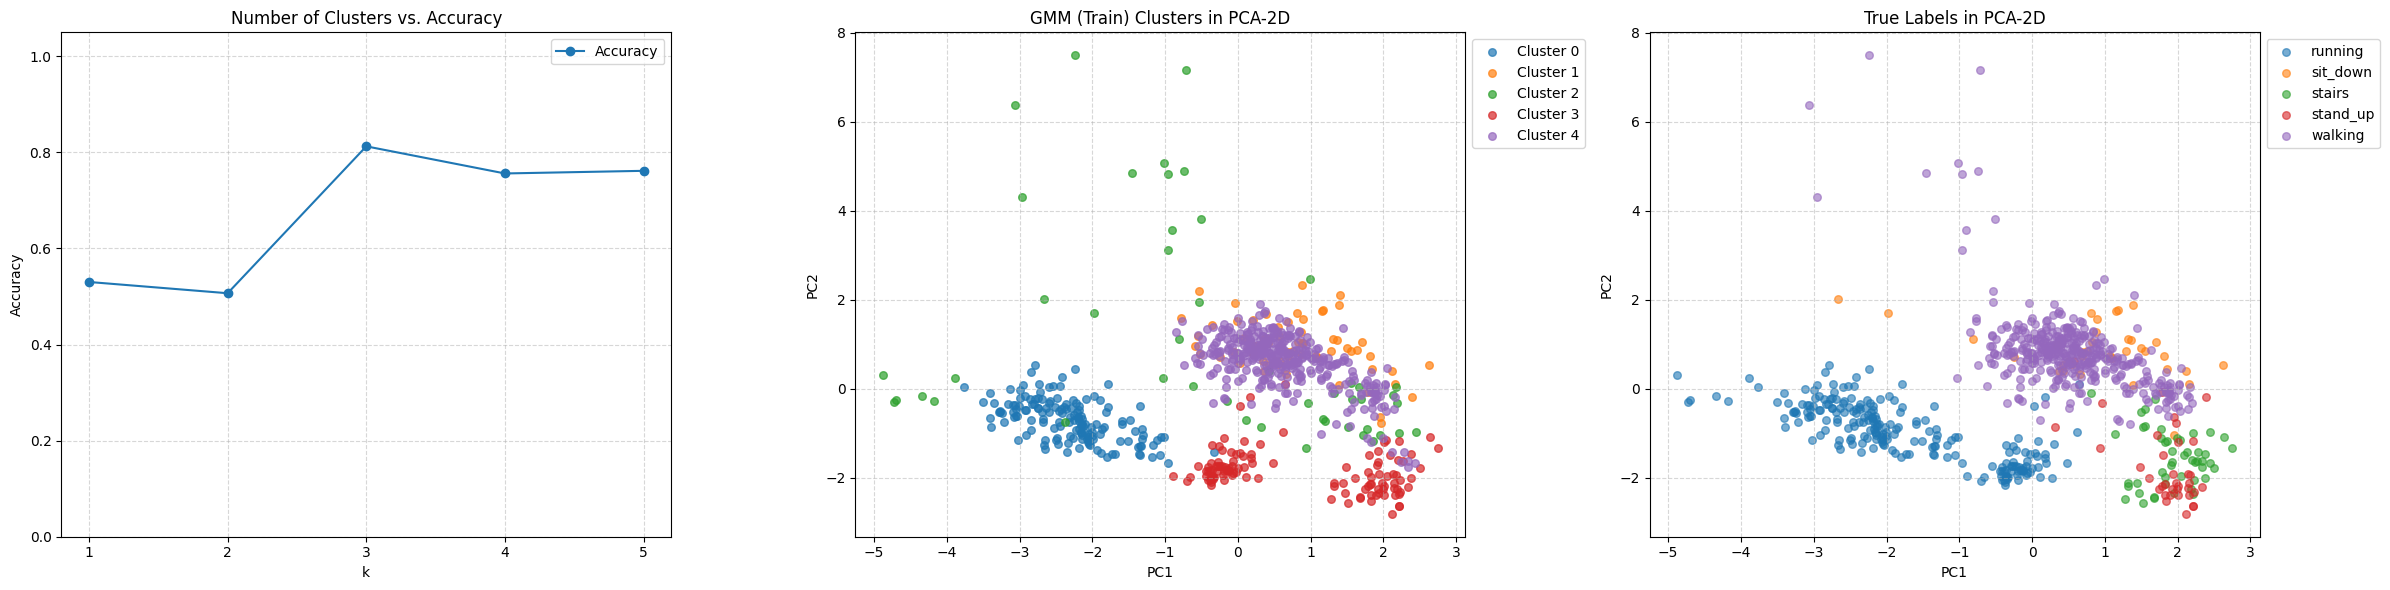

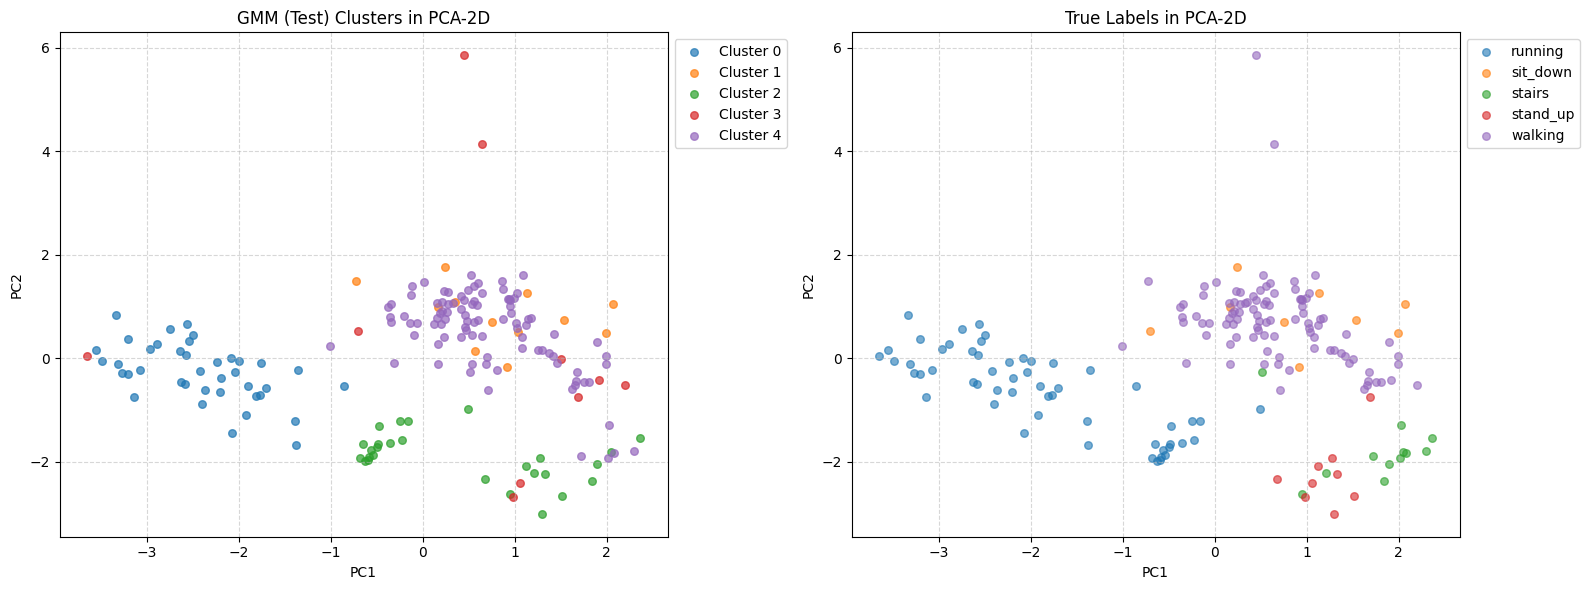

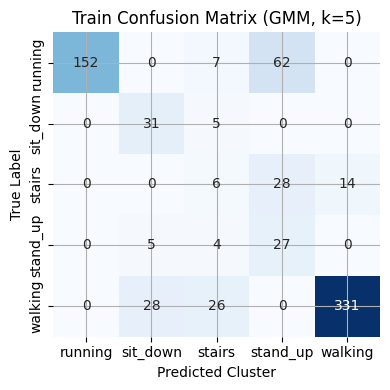

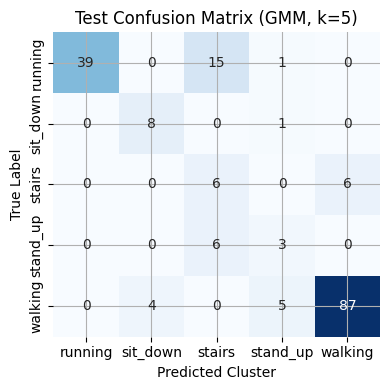

In [134]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, confusion_matrix

cluster_range = range(1, 6)
gmm_results = []

rng = np.random.RandomState(42)  # for reproducibility of GMM init params

for k in cluster_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        reg_covar=1e-6,           
        n_init=10,                
        random_state=42
    )
    gmm.fit(X_train_gmm_best)
    clusters = gmm.predict(X_train_gmm_best)
    gmm_results.append(clusters)

# Train accuracies
accuracies = []
for clusters in gmm_results:
    aligned = align_clusters(y_train_num, clusters)
    accuracies.append(accuracy_score(y_train_num, aligned))

print("\nTrain Accuracies for k=1..5 (GMM):", dict(zip(cluster_range, accuracies)))

# Final k = 5: fit on TRAIN, predict on TEST
k_final = 5
gmm_final = GaussianMixture(
    n_components=k_final,
    covariance_type="full",
    reg_covar=1e-6,
    n_init=1,
    random_state=42
)
gmm_final.fit(X_train_gmm_best)

# Train evaluation
clusters_train = gmm_final.predict(X_train_gmm_best)
y_train_aligned = align_clusters(y_train_num, clusters_train)
acc_train, f1_train, kappa_train = eval_model("GMM (k=5) - TRAIN", y_train_num, y_train_aligned)

# Test evaluation
clusters_test = gmm_final.predict(X_test_gmm_best)
y_test_aligned = align_clusters(y_test_num, clusters_test)
acc_test, f1_test, kappa_test = eval_model("GMM (k=5) - TEST", y_test_num, y_test_aligned)

# Plots
plot_clustering_results("GMM (Train)",
                        X_train_gmm_best, y_train_num, le,
                        cluster_range, accuracies, y_train_aligned,
                        show_k_vs_acc=True)

plot_clustering_results("GMM (Test)",
                        X_test_gmm_best, y_test_num, le,
                        [k_final], [acc_test], y_test_aligned,
                        show_k_vs_acc=False)

# Confusion Matrices
cm_train = confusion_matrix(y_train_num, y_train_aligned)
plot_confusion_matrix(cm_train, le, "Train Confusion Matrix (GMM, k=5)", cmap='Blues')

cm_test = confusion_matrix(y_test_num, y_test_aligned)
plot_confusion_matrix(cm_test, le, "Test Confusion Matrix (GMM, k=5)", cmap='Blues')